<a href="https://colab.research.google.com/github/Anhelina4/furniture-e-commerce-eda/blob/main/Furniture_E_commerce_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction & Executive Summary


**Project Overview**


> This notebook presents a comprehensive exploratory analysis of an online store's sales data extracted from Google BigQuery.
The analysis covers 349,545 sessions over the period 2020-11-01 to 2021-01-31 (92 days, holiday-heavy).


> **Data Source:**
Google BigQuery — DA dataset
Tables used: session, session_params, order, product,
account, account_session

> **Tableau Presenation:**
[Furniture E-commerce: What Moves Revenue and What Doesn't](https://public.tableau.com/app/profile/anhelina.bohdanova/viz/FurnitureE-commerceWhatMovesRevenueandWhatDoesnt/Whenpeoplebuy)


**Business Questions**
1. Who are our users and where do they come from?
2. What do they buy and how much do they spend?
3. Where does revenue come from and is it diversified?
4. Do registered users behave differently from unregistered?
5. Does newsletter subscription amplify purchase behavior?
6. Is there evidence of seasonality in our revenue?

**Summary**

Three months of session-level data show a store whose users behave the same way everywhere: no device, browser, traffic channel, country, or registration segment differs by more than 1–3% in conversion or revenue per session. That uniformity is the main result, and it is useful — it removes an entire class of expensive segment-specific initiatives from the roadmap.

The levers that do exist are structural. The largest by an order of magnitude is the weekly rhythm: revenue swings 41% between the midweek peak and the weekend trough, the pattern is stable and predictable in advance, and the cause is traffic volume rather than conversion. The second is category tiers and product pricing. Three distinct tiers were observed: premium, mid-range and low-range.

Everything below is directional. A 92-day holiday window cannot distinguish structural trend from holiday calendar, and the absence of order_id forces session-level proxies throughout.


# Connection & Setup

In [ ]:
from google.colab import auth
auth.authenticate_user()
print("Authenticated successfully")

Authenticated successfully


In [ ]:
from google.cloud import bigquery
from google.colab import userdata

try:
    project_id = userdata.get('project_id')
except Exception:
    project_id = 'your-gcp-project-id'  # replace to run this notebook


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import statsmodels.stats.multitest as smt
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

In [ ]:
from google.cloud import bigquery

client = bigquery.Client(project=project_id)

query = """
/*
GRAIN: one row = one session, maximum one bought product item
*/

WITH
  session_info AS (
    -- Verified: all 349545 sessions have matching session_params
    -- INNER JOIN is safe here — no sessions are lost
    SELECT
      s.date AS session_date,  /* when connect to order_with_product table session_date will become order_date */
      s.ga_session_id AS session_id,
      device,
      operating_system,
      browser,
      language AS browser_language,
      continent,
      country,
      channel AS traffic_channel,
      medium AS traffic_source,
      name AS traffic_source_name,
      mobile_model_name AS device_model_name
    FROM `DA.session` s
    JOIN `DA.session_params` sp
      ON s.ga_session_id = sp.ga_session_id
  ),
  order_with_product AS (
    -- Verified: all 33538 orders have matching product items
    -- INNER JOIN is safe here — no orders are lost
    SELECT
      ga_session_id AS session_id,
      o.item_id AS product_id,
      name AS product_name,
      category AS product_category,
      price AS product_price_per_item,
      short_description AS short_product_description
    FROM `DA.order` o
    JOIN `DA.product` p
      ON o.item_id = p.item_id
  ),
  registrations AS (
    -- There are 27945 distinct registered users linked to sessions
    -- 321600 sessions (92.1%) have no registered user — account columns will be NULL
    -- Only 7.9% of sessions have registered users
    -- LEFT JOIN preserves all sessions — NULLs in registration columns = unregistered user, not missing data
    SELECT
      account_id AS registered_account_id,
      ga_session_id AS session_id,
      send_interval AS email_send_interval,
      is_verified AS is_account_verified,
      is_unsubscribed AS is_unsubscribed_from_newsletter
    FROM `DA.account_session` ac
    JOIN `DA.account` a
      ON ac.account_id = a.id
  )

SELECT
  session_date AS session_and_order_date,
  session_info.session_id AS session_id,
  device,
  device_model_name,
  operating_system,
  browser,
  browser_language,
  continent,
  country,
  traffic_channel,
  traffic_source,
  traffic_source_name,
  product_id,
  product_name,
  product_category,
  product_price_per_item,
  short_product_description,
  registered_account_id,
  email_send_interval,
  is_account_verified,
  is_unsubscribed_from_newsletter
FROM session_info
LEFT JOIN order_with_product
  ON session_info.session_id = order_with_product.session_id
LEFT JOIN registrations
  ON session_info.session_id = registrations.session_id
"""

sales_df = client.query(query).to_dataframe(create_bqstorage_client=False)

print(sales_df.shape)
sales_df.head()

(349545, 21)


,session_and_order_date,session_id,device,device_model_name,operating_system,browser,browser_language,continent,country,traffic_channel,...,traffic_source_name,product_id,product_name,product_category,product_price_per_item,short_product_description,registered_account_id,email_send_interval,is_account_verified,is_unsubscribed_from_newsletter
0,2020-11-01,5760483956,desktop,Safari,Macintosh,Chrome,zh,Americas,United States,Paid Search,...,<Other>,99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>
1,2020-11-01,7115337200,desktop,Chrome,Web,Chrome,en-us,Europe,United Kingdom,Organic Search,...,(organic),99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>
2,2020-11-01,3978035233,mobile,<Other>,Web,Chrome,zh,Europe,Norway,Direct,...,(direct),20382932,RÅSKOG,Tables & desks,189.0,"Trolley, 35x45x78 cm",<NA>,<NA>,<NA>,<NA>
3,2020-11-01,9648986282,mobile,<Other>,Android,Chrome,es-es,Africa,Nigeria,Direct,...,(direct),99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>
4,2020-11-01,4393441533,desktop,Chrome,Windows,Chrome,en-us,Asia,China,Direct,...,(direct),99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>


In [ ]:
sales_df.head()

,session_and_order_date,session_id,device,device_model_name,operating_system,browser,browser_language,continent,country,traffic_channel,...,traffic_source_name,product_id,product_name,product_category,product_price_per_item,short_product_description,registered_account_id,email_send_interval,is_account_verified,is_unsubscribed_from_newsletter
0,2020-11-01,5760483956,desktop,Safari,Macintosh,Chrome,zh,Americas,United States,Paid Search,...,<Other>,99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>
1,2020-11-01,7115337200,desktop,Chrome,Web,Chrome,en-us,Europe,United Kingdom,Organic Search,...,(organic),99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>
2,2020-11-01,3978035233,mobile,<Other>,Web,Chrome,zh,Europe,Norway,Direct,...,(direct),20382932,RÅSKOG,Tables & desks,189.0,"Trolley, 35x45x78 cm",<NA>,<NA>,<NA>,<NA>
3,2020-11-01,9648986282,mobile,<Other>,Android,Chrome,es-es,Africa,Nigeria,Direct,...,(direct),99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>
4,2020-11-01,4393441533,desktop,Chrome,Windows,Chrome,en-us,Asia,China,Direct,...,(direct),99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>


# Data Overview & Quality Audit

**Inference:**

The dataset contains **349,545 rows** and **21 columns** covering **2020-11-01 to 2021-01-31**,
representing **349,545 unique sessions** across 3 months of e-commerce activity.
The data is properly structured with correct data types and no unexpected nulls —
partial population in product and registration columns is intentional by design
and explained in detail in subsections below.

Two analytical limitations apply throughout this analysis:
* ⚠️ **Order-level metrics** (AOV, basket size, quantity) cannot be calculated — the dataset
  lacks order_id and quantity fields, and each session contains exactly one product purchase
  of quantity 1. **Average revenue per session** is used as a proxy for AOV.
* ⚠️ **Localization analysis** should be interpreted **with caution** — browser_language is missing
  in ~32.6% of rows due to a likely platform-side collection issue. Results reflect only the 67.4% of sessions where language was captured. Not a blocker for this analysis, but worth investigating.

## Dataset shape, types, basic stats

**Inference:**

The dataset contains **349,545 rows** and **21 columns**, structured at the ordered product item grain with no nested fields. All column data types are correctly assigned.
The date range spans **2020-11-01** to **2021-01-31**, covering 3 months of daily sales data with **349,545** unique sessions, **33,538** product item purchases, and **2,528** unique products.

Two columns are partially populated by design, not by error:

- **Product columns** are non-null in 33,538 rows (~9.5%) — these are sessions where a purchase occurred. The remaining **90.5% are browse-only sessions with no purchased products**.
- **Registration columns** are non-null in 27,945 rows (~7.9%) — these are sessions linked to a registered account. The remaining **92.1% are anonymous sessions**.

**Product price distribution** is right-skewed: the mean of **\$953** is approximately twicecthe median of **\$445**, indicating that the majority of products are lower-priced, while acsmall number of high-ticket items pull the mean upward. The price range spans **\$3** to
**\$9,585**, with 75% of items priced below **\$1,195**. This skew has two practical implications for the analysis:
- **Bootstrap CI over classical CI** — AOV is sensitive to high-price outliers, making
  Bootstrap confidence intervals the appropriate estimation method, as classical CI assumes
  normally distributed data.
- **Revenue vs. orders divergence** — segmentation by product category will likely reveal
  a small number of premium categories driving a disproportionate share of revenue relative
  to order volume.

In [ ]:
sales_df.shape

(349545, 21)

In [ ]:
sales_df.head()

,session_and_order_date,session_id,device,device_model_name,operating_system,browser,browser_language,continent,country,traffic_channel,...,traffic_source_name,product_id,product_name,product_category,product_price_per_item,short_product_description,registered_account_id,email_send_interval,is_account_verified,is_unsubscribed_from_newsletter
0,2020-11-01,5760483956,desktop,Safari,Macintosh,Chrome,zh,Americas,United States,Paid Search,...,<Other>,99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>
1,2020-11-01,7115337200,desktop,Chrome,Web,Chrome,en-us,Europe,United Kingdom,Organic Search,...,(organic),99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>
2,2020-11-01,3978035233,mobile,<Other>,Web,Chrome,zh,Europe,Norway,Direct,...,(direct),20382932,RÅSKOG,Tables & desks,189.0,"Trolley, 35x45x78 cm",<NA>,<NA>,<NA>,<NA>
3,2020-11-01,9648986282,mobile,<Other>,Android,Chrome,es-es,Africa,Nigeria,Direct,...,(direct),99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>
4,2020-11-01,4393441533,desktop,Chrome,Windows,Chrome,en-us,Asia,China,Direct,...,(direct),99902661,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>,<NA>


In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   session_and_order_date           349545 non-null  dbdate 
 1   session_id                       349545 non-null  Int64  
 2   device                           349545 non-null  object 
 3   device_model_name                349545 non-null  object 
 4   operating_system                 349545 non-null  object 
 5   browser                          349545 non-null  object 
 6   browser_language                 235279 non-null  object 
 7   continent                        349545 non-null  object 
 8   country                          349545 non-null  object 
 9   traffic_channel                  349545 non-null  object 
 10  traffic_source                   349545 non-null  object 
 11  traffic_source_name              349545 non-null  object 
 12  pr

In [ ]:
sales_df.describe()

,session_id,product_id,product_price_per_item,registered_account_id,email_send_interval,is_account_verified,is_unsubscribed_from_newsletter
count,349545.0,33538.0,33538.000000,27945.0,27945.0,27945.0,27945.0
mean,4992250296.631739,47753715.295247,953.298679,659005.065557,1.057434,0.71698,0.16944
std,2887450949.537772,28778685.186469,1317.001775,13216.529465,0.565772,0.450474,0.375147
min,1205.0,91415.0,3.000000,636133.0,1.0,0.0,0.0
25%,2493646855.0,20346072.0,170.000000,647576.0,1.0,0.0,0.0
50%,4988476074.0,49259743.0,445.000000,658952.0,1.0,1.0,0.0
75%,7491286508.0,70340807.0,1195.000000,670414.0,1.0,1.0,0.0
max,9999997129.0,99930961.0,9585.000000,681962.0,7.0,1.0,1.0


In [ ]:
unique_sessions = sales_df['session_id'].nunique()
order_cnt = sales_df['product_id'].count()
unique_products = sales_df['product_id'].nunique()
print(f'Unique sessions: {unique_sessions}')
print(f'Orders number: {order_cnt}')
print(f'Unique products: {unique_products}')

Unique sessions: 349545
Orders number: 33538
Unique products: 2528


In [ ]:
data_info = sales_df['session_and_order_date'].agg(['min', 'max', 'count', 'nunique'])
display(data_info)

,session_and_order_date
min,2020-11-01
max,2021-01-31
count,349545
nunique,92


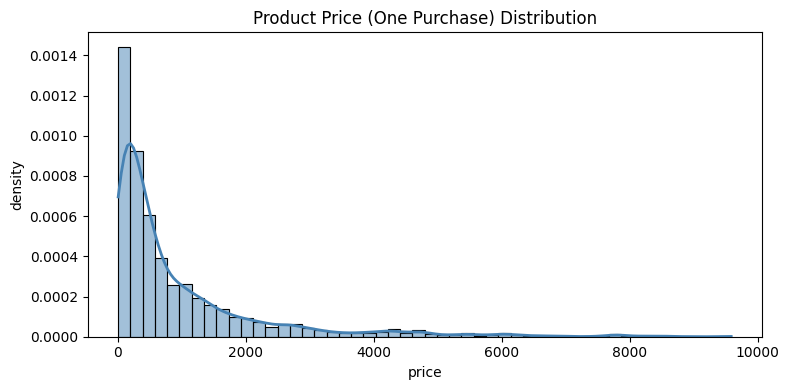

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(sales_df['product_price_per_item'], bins=50, kde=True, stat='density', color='steelblue', line_kws={'linewidth': 2})

plt.title('Product Price (One Purchase) Distribution')
plt.xlabel('price')
plt.ylabel('density')


plt.tight_layout()
plt.show()

## Missing values analysis

**Inference:**

**Expected nulls — by design, not by error:**

- **Product columns** (product_id, product_name, product_category,
  product_price_per_item, short_product_description) are null in ~**90.5%** of rows — these are browse-only sessions with no purchase.
- **Registration columns** (registered_account_id, email_send_interval,
  is_account_verified, is_unsubscribed_from_newsletter) are null in ~**92.1%** of rows — these are anonymous sessions with no registered account.

**Unexpected nulls — worth investigating:**

- browser_language is missing in ~**32.6%** of rows, despite continent and country being fully populated across all 349,545 rows. The issue is worth investigating.

All remaining columns are fully populated with **0% null values**.

> ⚠️ All localization analysis in Section 7 should be interpreted with this caveat —
> results reflect only the **67.4%** of sessions where language was captured.

In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   session_and_order_date           349545 non-null  dbdate 
 1   session_id                       349545 non-null  Int64  
 2   device                           349545 non-null  object 
 3   device_model_name                349545 non-null  object 
 4   operating_system                 349545 non-null  object 
 5   browser                          349545 non-null  object 
 6   browser_language                 235279 non-null  object 
 7   continent                        349545 non-null  object 
 8   country                          349545 non-null  object 
 9   traffic_channel                  349545 non-null  object 
 10  traffic_source                   349545 non-null  object 
 11  traffic_source_name              349545 non-null  object 
 12  pr

In [ ]:
null_values_columns = sales_df.isna().sum(axis=0) / sales_df.shape[0] * 100
null_values_columns_summary = null_values_columns.reset_index().rename(columns={'index': 'column_name', 0: 'null_value_percentage'}).sort_values('null_value_percentage', ascending=True)

null_values_rows = sales_df.isna().sum(axis=1) / sales_df.shape[1] * 100
null_values_rows_summary = null_values_rows.value_counts().rename_axis('null_value_percentage').reset_index(name='row_count').sort_values('row_count', ascending=True)

print("Columns null values: ")
display(null_values_columns_summary)
print("Row null values: ")
display(null_values_rows_summary)

Columns null values: 


,column_name,null_value_percentage
0,session_and_order_date,0.000000
1,session_id,0.000000
2,device,0.000000
3,device_model_name,0.000000
4,operating_system,0.000000
5,browser,0.000000
7,continent,0.000000
8,country,0.000000
10,traffic_source,0.000000
9,traffic_channel,0.000000


Row null values: 


,null_value_percentage,row_count
6,4.761905,915
5,0.000000,1866
4,28.571429,8286
3,19.047619,20665
2,23.809524,26970
1,47.619048,94973
0,42.857143,195870


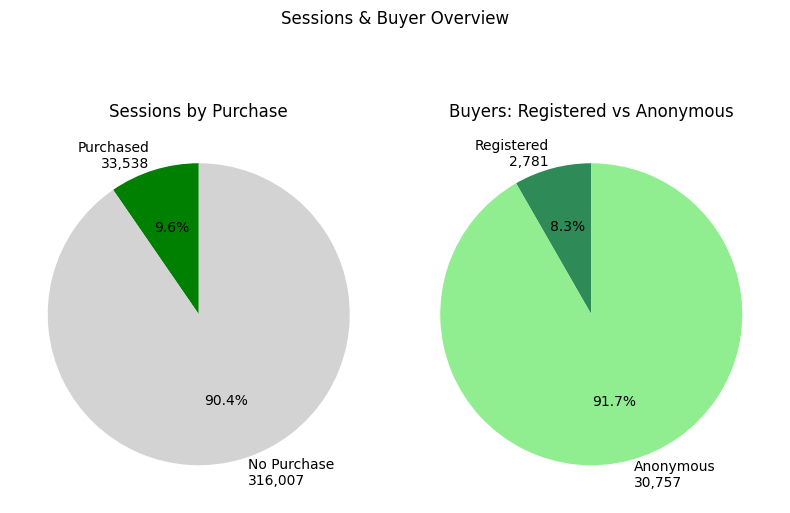

In [ ]:
rows_with_product_info = sales_df[sales_df['product_id'].notna()]
rows_with_product_and_registered_user_info = rows_with_product_info[rows_with_product_info['registered_account_id'].notna()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))
fig.suptitle('Sessions & Buyer Overview')

total = len(sales_df)
purchased = sales_df['product_id'].notna().sum()

ax1.pie(
    [purchased, total - purchased],
    labels=[f'Purchased\n{purchased:,}', f'No Purchase\n{total - purchased:,}'],
    colors=['green', 'lightgrey'],
    autopct='%1.1f%%',
    startangle=90
)
ax1.set_title('Sessions by Purchase')

registered = rows_with_product_and_registered_user_info.shape[0]
anonymous = purchased - registered

ax2.pie(
    [registered, anonymous],
    labels=[f'Registered\n{registered:,}', f'Anonymous\n{anonymous:,}'],
    colors=['seagreen', 'lightgreen'],
    autopct='%1.1f%%',
    startangle=90
)
ax2.set_title('Buyers: Registered vs Anonymous')

plt.tight_layout()
plt.show()

## Suspicious patterns audit

**Inference:**

Three suspicious patterns were identified during the audit:

- **browser_language — collection bug:** missing in ~32.6% of rows despite full geo coverage. Investigated in the Missing Values section above.

- **traffic_channel — undefined values:** an "Undefined" channel exists for a subset of records. The exact cause is unclear and warrants further investigation; the column is retained as-is for the planned analysis.

- **traffic_source / traffic_source_name — redacted data:** both fields contain `(data deleted)` values in some records, which typically indicates data redacted due to privacy regulations (e.g. GDPR) or platform-level retention policies — not a collection bug. Since neither column is used in the planned analysis, the impact is contained.

**No duplicates** were found for session_id or session_id + product_id. Every session contains exactly one product purchase of quantity 1 — atypical for real e-commerce behavior,suggesting the dataset is pre-aggregated, sampled, or simplified. As a result, basket size and cross-sell pattern analysis are not possible.

> ⚠️ **AOV cannot be calculated in the traditional sense** — the dataset lacks order_id and quantity fields. **Average revenue per session is used as a proxy throughout the analysis.**

In [ ]:
categorical_cols = sales_df[['device', 'device_model_name', 'operating_system', 'browser', 'browser_language', 'continent', 'country', 'traffic_channel', 'traffic_source', 'traffic_source_name', 'product_category']]

for col in categorical_cols.columns:
  print(f'Col name: {col}')
  print(sales_df[col].unique())

Col name: device
['desktop' 'mobile' 'tablet']
Col name: device_model_name
['Safari' 'Chrome' '<Other>' 'iPhone' 'Pixel 3' 'ChromeBook' 'iPad'
 'Pixel 4 XL' 'Edge' 'Firefox']
Col name: operating_system
['Macintosh' 'Web' 'Android' 'Windows' 'iOS' '<Other>']
Col name: browser
['Chrome' 'Safari' 'Android Webview' '<Other>' 'Edge' 'Firefox']
Col name: browser_language
['zh' 'en-us' 'es-es' None 'en-gb' 'en-ca' 'fr' 'ko' 'en' 'de']
Col name: continent
['Americas' 'Europe' 'Africa' 'Asia' 'Oceania' '(not set)']
Col name: country
['United States' 'United Kingdom' 'Norway' 'Nigeria' 'China' 'Germany'
 '(not set)' 'Ecuador' 'Japan' 'Canada' 'Italy' 'Indonesia' 'South Korea'
 'Belgium' 'Pakistan' 'United Arab Emirates' 'Uruguay' 'Israel' 'Czechia'
 'India' 'Taiwan' 'Georgia' 'Portugal' 'Thailand' 'Bangladesh' 'Turkey'
 'Vietnam' 'Philippines' 'France' 'Switzerland' 'Greece' 'Sweden'
 'Malaysia' 'Slovenia' 'Argentina' 'Singapore' 'Spain' 'Brazil' 'Denmark'
 'Dominican Republic' 'Australia' 'Mexi

In [ ]:
duplicated_sessions = sales_df[sales_df.duplicated(subset=['session_id'], keep=False)]

# check if some products were bought several times in one session
duplicated_session_with_product = sales_df[sales_df.duplicated(subset=['session_id',  'product_id'], keep=False)]
print("duplicated_sessions", duplicated_sessions)
print("duplicated_session_with_product", duplicated_session_with_product)

duplicated_sessions Empty DataFrame
Columns: [session_and_order_date, session_id, device, device_model_name, operating_system, browser, browser_language, continent, country, traffic_channel, traffic_source, traffic_source_name, product_id, product_name, product_category, product_price_per_item, short_product_description, registered_account_id, email_send_interval, is_account_verified, is_unsubscribed_from_newsletter]
Index: []

[0 rows x 21 columns]
duplicated_session_with_product Empty DataFrame
Columns: [session_and_order_date, session_id, device, device_model_name, operating_system, browser, browser_language, continent, country, traffic_channel, traffic_source, traffic_source_name, product_id, product_name, product_category, product_price_per_item, short_product_description, registered_account_id, email_send_interval, is_account_verified, is_unsubscribed_from_newsletter]
Index: []

[0 rows x 21 columns]


# Who Are Our Users?

**Inference:**

The store's **user base is geographically concentrated** — 65.1% of revenue comes from just 5 countries (US, India, Canada, UK, France), with the US alone accounting for 43.6%. The similar distribution applies to registrations - same countries hold \~66% of registrations, with US alone accounting for \~44% of registrations. Despite this concentration, purchase behavior is consistent across all measured dimensions.

**Technology choice** (device, browser, mobile OS) does not influence purchase behavior — revenue per session and conversion rates are statistically indistinguishable across all segments. Desktop (58.5%) and Chrome (68.2%) dominate on volume, not quality.

**Traffic channels** show identical conversion rates (9.58–9.73% and near-identical revenue per session (\$90–93) — volume is the only meaningful differentiator between channels. **All channels move together** in daily revenue, suggesting shared external demand drivers (seasonality, promotions) rather than independent channel dynamics.

**Registered users** represent only 8% of sessions yet account for 8.3% of purchases — suggesting registration does not drive conversion. **Email verification rate is 71,7%**. **Newsletter subscription is exclusive to registered users, with 83% retention among those who registered** — but subscribers represent only 6.6% of all sessions due to the dominant unregistered base.

**The overarching finding:** this store's conversion and revenue generation is driven by external demand factors and product/pricing decisions rather than by which device, channel, or user segment is being served — a consistent, channel-agnostic demand pattern that simplifies optimization strategy but also limits levers for segment-specific improvement.

## Geography

**Business question:** What geographical markets do we cover with our sales and in what volume: which geographical markets generate the most revenue, sessions - and where should we focus our regional strategy?

**Inference:**

The **top-3 continents** by revenue are America (55.3% of total revenue), Asia (23.8% of total revenue) and Europe (18.5% of total revenue), collectively generating 97.6% of total revenue.

The **top-5 countries** are United States (43.6% of total revenue), India (8.8% of total revenue), Canada (7.6% of total revenue), United Kingdom (2.9% of total revenue) and France (2.2% of total revenue).

Geographic concentration is moderately high — **65.1% of revenue is generated by just top 5 countries**, with the US alone accounting for 43.6%. **This represents significant single-market dependency.** Notably, **session share and revenue share align closely** across all top-5 countries and top-3 continents, **indicating consistent purchase behavior across markets relative to its traffic volume.**


In [ ]:
def analyse_split(
    df: pd.DataFrame,
    metric: str,
    dimension: str,
    highlight_top: int = 0,
    ax = None,
    title: str = "",
    aggfunc: str = 'sum',
    only_top: bool = False
):
    # aggregate
    result = (
        df.groupby(dimension)[metric]
        .agg(aggfunc)
        .reset_index()
        .rename(columns={metric: 'metric_cnt'})
        .sort_values('metric_cnt', ascending=False)
    )
    result['metric_pct'] = (
        result['metric_cnt'] / result['metric_cnt'].sum() * 100
    )

    # create ax if not passed
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    if only_top and highlight_top:
        result = result.head(highlight_top)
        colors = ['steelblue'] * len(result)
    elif highlight_top:
        colors = ['steelblue'] * highlight_top + ['lightgrey'] * (len(result) - highlight_top)
    else:
        colors = 'steelblue'

    result.plot(kind='bar', x=dimension, y='metric_cnt', color=colors, ax=ax, legend=False)

    ax.margins(x=0.1, y=0.15)
    ax.bar_label(
        ax.containers[0],
        labels=[f'{v:,.0f}\n({p:.1f}%)'
                for v, p in zip(result['metric_cnt'], result['metric_pct'])],
        padding=0,
        fontsize=10,
    )
    default_title = f'{metric} by {dimension}'
    if highlight_top:
        default_title += f' (Top {highlight_top} Highlighted)'
    ax.set_title(title or default_title)
    ax.set_xlabel(dimension)
    ax.set_ylabel(metric)

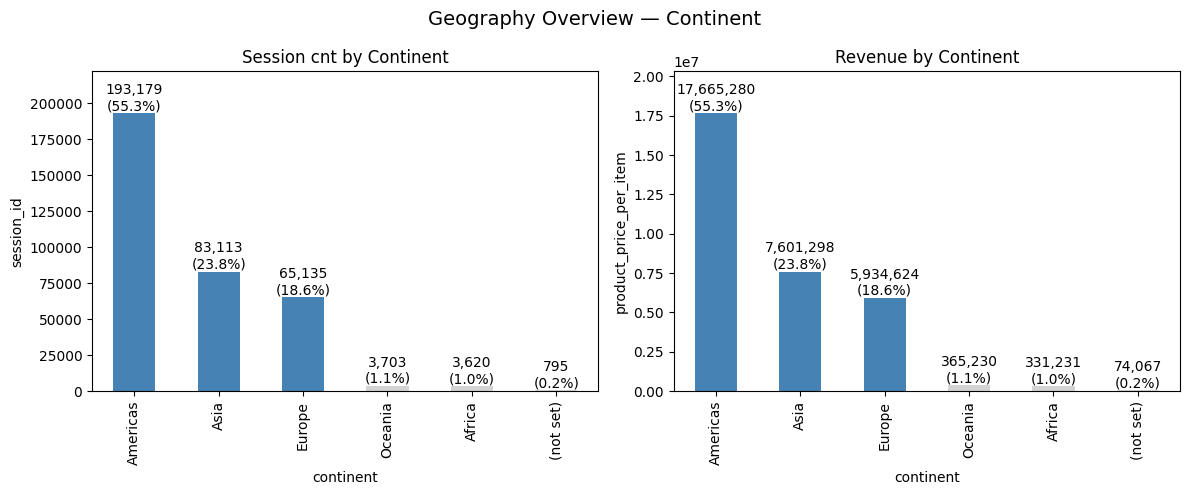

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
analyse_split(df=sales_df, metric='session_id', dimension='continent', highlight_top=3, ax=axes[0], title='Session cnt by Continent', aggfunc='count')

analyse_split(df=sales_df, metric='product_price_per_item', dimension='continent', highlight_top=3, ax=axes[1], title='Revenue by Continent', aggfunc='sum')

plt.suptitle('Geography Overview — Continent', fontsize=14)
plt.tight_layout()
plt.show()

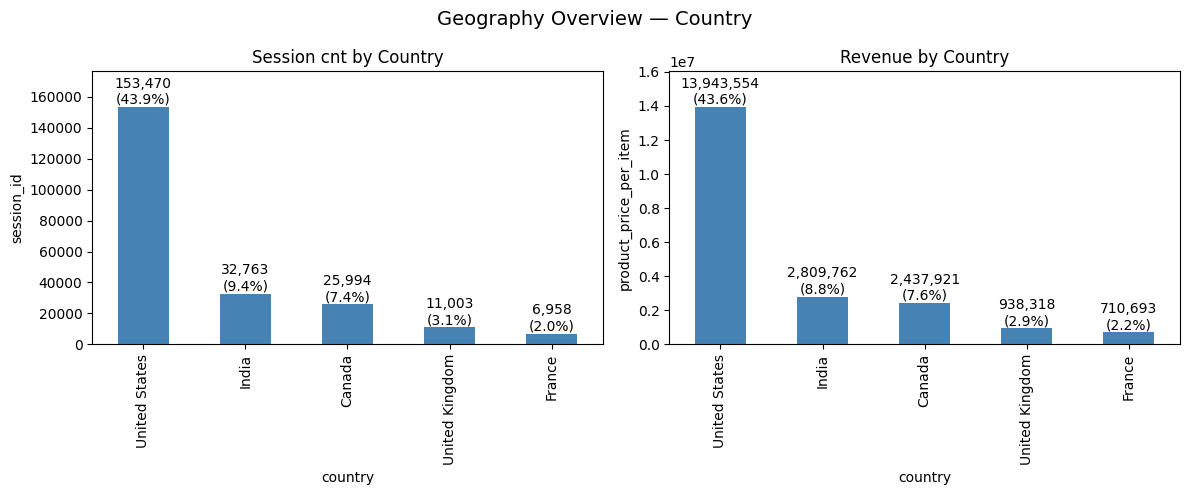

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
analyse_split(df=sales_df, metric='session_id', dimension='country', highlight_top=5, ax=axes[0], title='Session cnt by Country', aggfunc='count', only_top=True)

analyse_split(df=sales_df, metric='product_price_per_item', dimension='country', highlight_top=5, ax=axes[1], title='Revenue by Country', aggfunc='sum', only_top=True)

plt.suptitle('Geography Overview — Country', fontsize=14)
plt.tight_layout()
plt.show()

## Devices & Technology

**Business question:** Which devices and browsers do our users prefer — and does device choice meaningfully affect revenue per session, justifying device-specific UX investment?

**Inference:**

**58.5% of sessions originate from desktop** and **68.2% from Chrome browser**, with revenue share closely mirroring session share in both cases.

These statistical tests were conducted to assess whether technology choice influences purchase behavior (using revenue per session as a proxy metric for AOV): Kruskal-Wallis for device (desktop vs mobile vs tablet), Kruskal-Wallis for browser (Chrome, Safari, Edge, Firefox, Android Webview, Other), and Mann-Whitney U for mobile OS (iOS vs Android). *Bonferroni correction applied*: significance threshold p < 0.0167 (0.05 / 3). **None of the three tests reached significance** — in this dataset purchase behavior does not differ meaningfully across devices, browsers, or mobile operating systems.

Revenue per session is nearly identical across devices (\$90-92) indicating no device-level value gap in this dataset. Browser revenue per session shows a wider range (\$88-\$103), driven by the <Other> category which contains niche browsers with small sample sizes confirmed by the non-significant Kruskal-Wallis result.

Giving this data - **No device-specific or browser-specific UX investment is justified by current revenue data.**

Any UX improvements should be applied globally across all devices and browsers. Desktop and Chrome should be prioritized purely on volume grounds (58.5% and 68.2% of sessions respectively), not because they generate higher value per session.


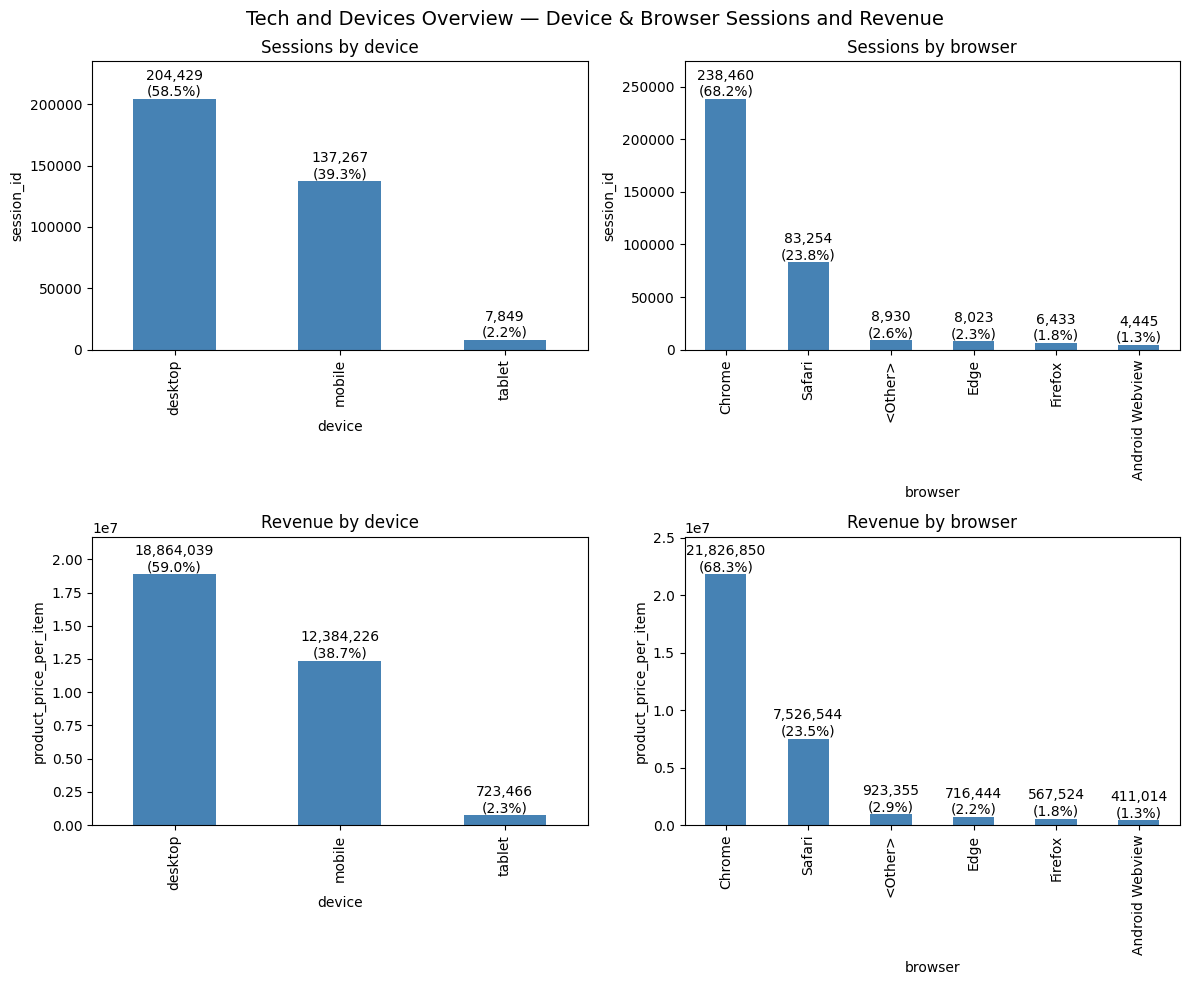

In [ ]:
# session and revenue by device and browser
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

analyse_split(ax=axes[0, 0], df=sales_df, metric='session_id', dimension='device', aggfunc='count', title='Sessions by device')
analyse_split(ax=axes[0, 1], df=sales_df, metric='session_id', dimension='browser', aggfunc='count', title='Sessions by browser')
analyse_split(ax=axes[1, 0], df=sales_df, metric='product_price_per_item', dimension='device', aggfunc='sum', title='Revenue by device')
analyse_split(ax=axes[1, 1], df=sales_df, metric='product_price_per_item', dimension='browser', aggfunc='sum', title='Revenue by browser')

plt.suptitle('Tech and Devices Overview — Device & Browser Sessions and Revenue', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Q: On average - how much revenue does each device visit generate?
device_stats = sales_df.groupby('device').agg(sessions=('session_id', 'count'), revenue=('product_price_per_item', 'sum')).rename(columns={'product_price_per_item': 'revenue'})

device_stats['revenue_per_session'] = device_stats['revenue'] / device_stats['sessions']
display("Device overview", device_stats)

'Device overview'

,sessions,revenue,revenue_per_session
device,,,
desktop,204429,18864039.0,92.276727
mobile,137267,12384225.8,90.219979
tablet,7849,723466.3,92.173054


In [ ]:
# Q: Among users who made a purchase - do they spend differently depending on device - more or less?
desktop_revenue = sales_df[sales_df['device'] == 'desktop']['product_price_per_item'].dropna()
mobile_revenue = sales_df[sales_df['device'] == 'mobile']['product_price_per_item'].dropna()
tablet_revenue = sales_df[sales_df['device'] == 'tablet']['product_price_per_item'].dropna()

stat, p_value = stats.kruskal(desktop_revenue, mobile_revenue, tablet_revenue)

print(f"Kruskal-Wallis statistic: {stat}")
print(f"P-value: {p_value}")

# Interpretation, adjusted for multiple comparisons using Bonferroni method
if p_value < 0.0167:
    print("There is a significant difference in user purchase behavior depending on the device.")
else:
    print("There is no significant difference in user purchase behavior depending on the device.")

Kruskal-Wallis statistic: 4.193598984874611
P-value: 0.12284897882315772
There is no significant difference in user purchase behavior depending on the device.


In [ ]:
# Q: On average - how much revenue does each browser visit generate?
browser_stats = sales_df.groupby('browser').agg(sessions=('session_id', 'count'), revenue=('product_price_per_item', 'sum')).rename(columns={'product_price_per_item': 'revenue'})

browser_stats['revenue_per_session'] = browser_stats['revenue'] / browser_stats['sessions']
display("Browser overview", browser_stats.sort_values(by='revenue_per_session', ascending=False))

'Browser overview'

,sessions,revenue,revenue_per_session
browser,,,
<Other>,8930,923354.8,103.399194
Android Webview,4445,411014.4,92.466682
Chrome,238460,21826850.0,91.532542
Safari,83254,7526544.0,90.404593
Edge,8023,716444.3,89.298803
Firefox,6433,567523.6,88.220675


In [ ]:
# Q: Among users who made a purchase - do they spend differently depending on browser - more or less?
other_revenue = sales_df[sales_df['browser'] == '<Other>']['product_price_per_item'].dropna()
android_webview_revenue = sales_df[sales_df['browser'] == 'Android Webview']['product_price_per_item'].dropna()
chrome_revenue = sales_df[sales_df['browser'] == 'Chrome']['product_price_per_item'].dropna()
safari_revenue = sales_df[sales_df['browser'] == 'Safari']['product_price_per_item'].dropna()
edge_revenue = sales_df[sales_df['browser'] == 'Edge']['product_price_per_item'].dropna()
firefox_revenue = sales_df[sales_df['browser'] == 'Firefox']['product_price_per_item'].dropna()

stat, p_value = stats.kruskal(other_revenue, android_webview_revenue, chrome_revenue, safari_revenue, edge_revenue, firefox_revenue)

print(f"Kruskal-Wallis statistic: {stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.0167:
    print("There is a significant difference in user purchase behavior depending on the browser.")
else:
    print("There is no significant difference in user purchase behavior depending on the browser.")

Kruskal-Wallis statistic: 3.1685059863226654
P-value: 0.6740254483053267
There is no significant difference in user purchase behavior depending on the browser.


In [ ]:
# Q: Mobile devices are represented by iOS and Android and Web - what user types bring more revenue per session
mobile_info = sales_df[sales_df['device'] == 'mobile']

mobile_op_system = mobile_info['operating_system'].value_counts()

mobile_stats = mobile_info.groupby('operating_system').agg(sessions=('session_id', 'count'), revenue=('product_price_per_item', 'sum')).reset_index()

mobile_stats['revenue_per_session'] = mobile_stats['revenue'] / mobile_stats['sessions']
mobile_stats_sorted = mobile_stats.sort_values(by='revenue_per_session', ascending=False)
display(mobile_stats_sorted)

# Q: Does the purchase behaviour between Android and iOS users - does one segment spend more or less?
iOS_revenue = mobile_info[mobile_info['operating_system'] == 'iOS']['product_price_per_item'].dropna()
Android_revenue = mobile_info[mobile_info['operating_system'] == 'Android']['product_price_per_item'].dropna()

stat, p_value = stats.mannwhitneyu(iOS_revenue, Android_revenue)

print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value}")

if p_value < 0.0167:
    print("There is a significant difference in user purchase behavior depending on the mobile operating system.")
else:
    print("There is no significant difference in user purchase behavior depending on the mobile operating system.")

,operating_system,sessions,revenue,revenue_per_session
1,Android,28592,2649766.5,92.675101
4,iOS,37758,3407107.7,90.235386
2,Web,70882,6326020.6,89.247208
0,<Other>,33,1331.0,40.333333
3,Windows,2,0.0,0.0


Mann-Whitney U statistic: 4885673.0
P-value: 0.9511031238410166
There is no significant difference in user purchase behavior depending on the mobile operating system.


## Traffic Channels

**Business Question:** Which traffic channels drive the most users and revenue — and do channels move together or independently, informing whether we need one global or multiple channel-specific strategies? Is the proportion of sessions with organic traffic statistically different in Europe and America?

**Inference:**

**Overview:**

Direct, Organic Search, and Paid Search collectively drive **~85% of sessions and revenue**, with session share and revenue share closely aligned across all channels — no channel significantly over- or underperforms relative to its traffic volume.

**Conversion rate** is virtually identical across all traffic channels (9.58–9.73%), confirmed by chi-square test: χ²(4) = 0.64, p = 0.96 — no statistically significant difference. Channel acquisition method has no effect on whether a user converts in this dataset. **Volume is the only meaningful differentiator between them. Conversion optimization efforts — checkout flow, UX, pricing — would benefit all channels equally, with no justification for channel-specific conversion strategies.**

Pairwise Spearman correlation of daily revenue (FDR-corrected, Benjamini-Hochberg, α = 0.05) shows **strong positive significant comovement between Direct, Organic, and Paid Search** — indicating these channels are simultaneously affected by shared external factors such as seasonal events or sitewide promotions rather than operating independently.
Remaining channel pairs show **moderate positive correlation**.
Overall correlation is positive across all pairs, suggesting a shared demand driver affects the entire channel mix.

The **Undefined traffic channel** requires classification before reliable conclusions can be drawn.

**Social**, while lower in volume, generates comparable revenue per session to top channels — if acquisition costs are low, scaling Social could pose a potential easy win for incremental revenue.

**Organic Search in America and Europe:**

The organic search rate in Europe is 35.6, in America 35.5, the difference is not statistically significant, inidcating there is no evidence that organic search brings more traffic in the specified region.

**Traffic x Device:**

Every channel has the same device mix — ~58.5% desktop, ~39.3% mobile, ~2.2% tablet, varying by less than 0.5pp between channels. Device choice is independent of how users arrive.


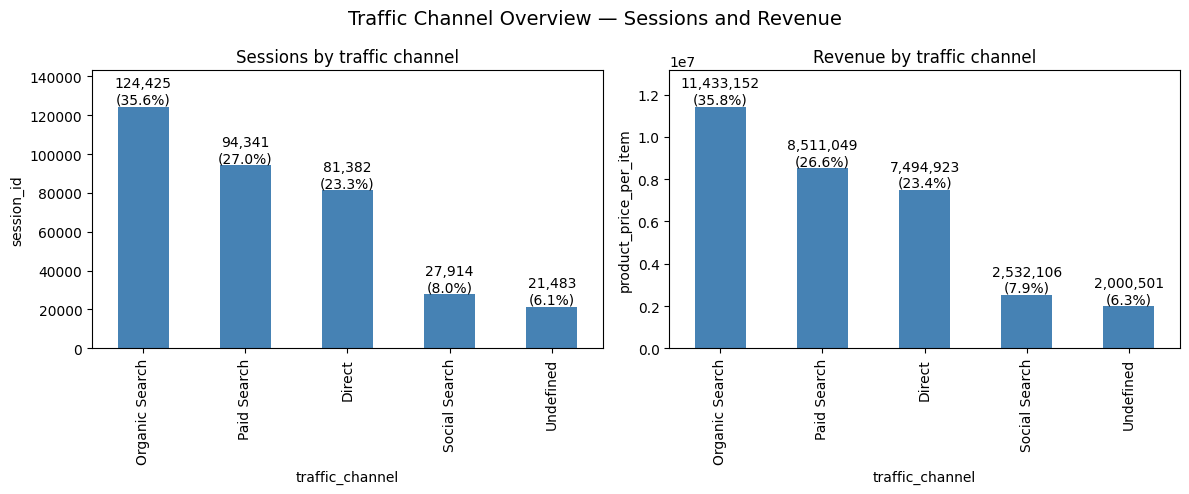

In [ ]:
# session and revenue by traffic channel
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

analyse_split(ax=axes[0], df=sales_df, metric='session_id', dimension='traffic_channel', aggfunc='count', title='Sessions by traffic channel')
analyse_split(ax=axes[1], df=sales_df, metric='product_price_per_item', dimension='traffic_channel', aggfunc='sum', title='Revenue by traffic channel')

plt.suptitle('Traffic Channel Overview — Sessions and Revenue', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# sessions by traffic x device pivot
traffic_device_sessions_raw = sales_df.pivot_table(index='traffic_channel', columns='device', values='session_id', aggfunc='count')
display("traffic_device_sessions_raw", traffic_device_sessions_raw)

traffic_device_sessions_share = pd.crosstab(sales_df['traffic_channel'], sales_df['device'], normalize='index')
display("traffic_device_sessions_share", traffic_device_sessions_share)

'traffic_device_sessions_raw'

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


'traffic_device_sessions_share'

device,desktop,mobile,tablet
traffic_channel,,,
Direct,0.587661,0.390074,0.022265
Organic Search,0.583661,0.393924,0.022415
Paid Search,0.584762,0.392555,0.022684
Social Search,0.583506,0.393638,0.022856
Undefined,0.583112,0.395010,0.021878


In [ ]:
# Q: On average - how much revenue does each traffic channel user generate?
channel_stats = sales_df.groupby('traffic_channel').agg(sessions=('session_id', 'count'), converted_session=('product_price_per_item', 'count'), revenue=('product_price_per_item', 'sum')).rename(columns={'product_price_per_item': 'revenue'})

channel_stats['revenue_per_session'] = channel_stats['revenue'] / channel_stats['sessions']
channel_stats['conversion_pct'] = channel_stats['converted_session'] / channel_stats['sessions'] * 100
display("Channel overview", channel_stats.sort_values(by='revenue_per_session', ascending=False))

# build contingency table: converted vs not converted per channel
contingency = pd.DataFrame({
    'converted': channel_stats['converted_session'].astype('int64'),
    'not_converted': (channel_stats['sessions'] - channel_stats['converted_session']).astype('int64')
})
display(contingency)
chi2, p, dof, expected = stats.chi2_contingency(contingency.reset_index(drop=True).values)
print(f"Chi-square: {chi2:.4f}, p-value: {p:.4f}, degrees of freedom: {dof}")

'Channel overview'

,sessions,converted_session,revenue,revenue_per_session,conversion_pct
traffic_channel,,,,,
Undefined,21483,2059,2000501.0,93.120188,9.584322
Direct,81382,7800,7494923.4,92.095591,9.584429
Organic Search,124425,11921,11433151.6,91.887897,9.580872
Social Search,27914,2716,2532105.7,90.710959,9.729885
Paid Search,94341,9042,8511049.4,90.215806,9.58438


,converted,not_converted
traffic_channel,,
Direct,7800,73582
Organic Search,11921,112504
Paid Search,9042,85299
Social Search,2716,25198
Undefined,2059,19424


Chi-square: 0.6397, p-value: 0.9586, degrees of freedom: 4


**Business question:** Is the proportion of sessions with organic traffic statistically different in Europe and America?

In [ ]:
americas = sales_df[sales_df['continent'] == 'Americas']
europe = sales_df[sales_df['continent'] == 'Europe']
result = {'America': {
    'total': len(americas),
    'organic': (americas['traffic_channel'] == 'Organic Search').sum(),
    'share': (americas['traffic_channel'] == 'Organic Search').sum() / len(americas) * 100
},
          'Europe': {
    'total': len(europe),
    'organic': (europe['traffic_channel'] == 'Organic Search').sum(),
    'share': (europe['traffic_channel'] == 'Organic Search').sum() / len(europe) * 100
}}

display("result", result)

# we compare rates in 2 groups, thus proportions_ztest is sifficient
result['America']['organic']
stat, p_value = proportions_ztest([result['America']['organic'], result['Europe']['organic']], [result['America']['total'], result['Europe']['total']])

print(f"proportions_ztest statistic: {stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There is a significant difference between rates.")
else:
    print("There is no significant difference between rates.")

'result'

{'America': {'total': 193179,
  'organic': np.int64(68671),
  'share': np.float64(35.54785975701293)},
 'Europe': {'total': 65135,
  'organic': np.int64(23195),
  'share': np.float64(35.610654793889616)}}

proportions_ztest statistic: -0.28951412926103953
P-value: 0.7721879690501752
There is no significant difference between rates.


traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
session_and_order_date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104780.8,16843.0,24575.0
2020-11-03,102909.5,182521.9,152641.3,27652.5,33254.4
2020-11-04,79683.6,117067.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35629.4
...,...,...,...,...,...
2021-01-27,70423.1,92921.1,80869.5,16282.0,25845.0
2021-01-28,0.0,0.0,0.0,0.0,0.0
2021-01-29,0.0,0.0,0.0,0.0,0.0


'channel_corr_df'

,channel_1,channel_2,rho,p_value,p_adjusted,significant
0,Direct,Organic Search,0.779663,5.405254e-20,2.702627e-19,True
1,Direct,Paid Search,0.729369,1.654022e-16,5.513405e-16,True
2,Direct,Social Search,0.469342,2.365556e-06,2.956945e-06,True
3,Direct,Undefined,0.556922,8.156167e-09,1.684381e-08,True
4,Organic Search,Paid Search,0.793381,4.161837e-21,4.161837e-20,True
5,Organic Search,Social Search,0.461543,3.645214e-06,3.645214e-06,True
6,Organic Search,Undefined,0.524677,7.935218e-08,1.322536e-07,True
7,Paid Search,Social Search,0.492725,6.058888e-07,8.655554e-07,True
8,Paid Search,Undefined,0.556491,8.421903e-09,1.684381e-08,True
9,Social Search,Undefined,0.462530,3.453229e-06,3.645214e-06,True


/tmp/ipykernel_70378/1260281002.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(False)


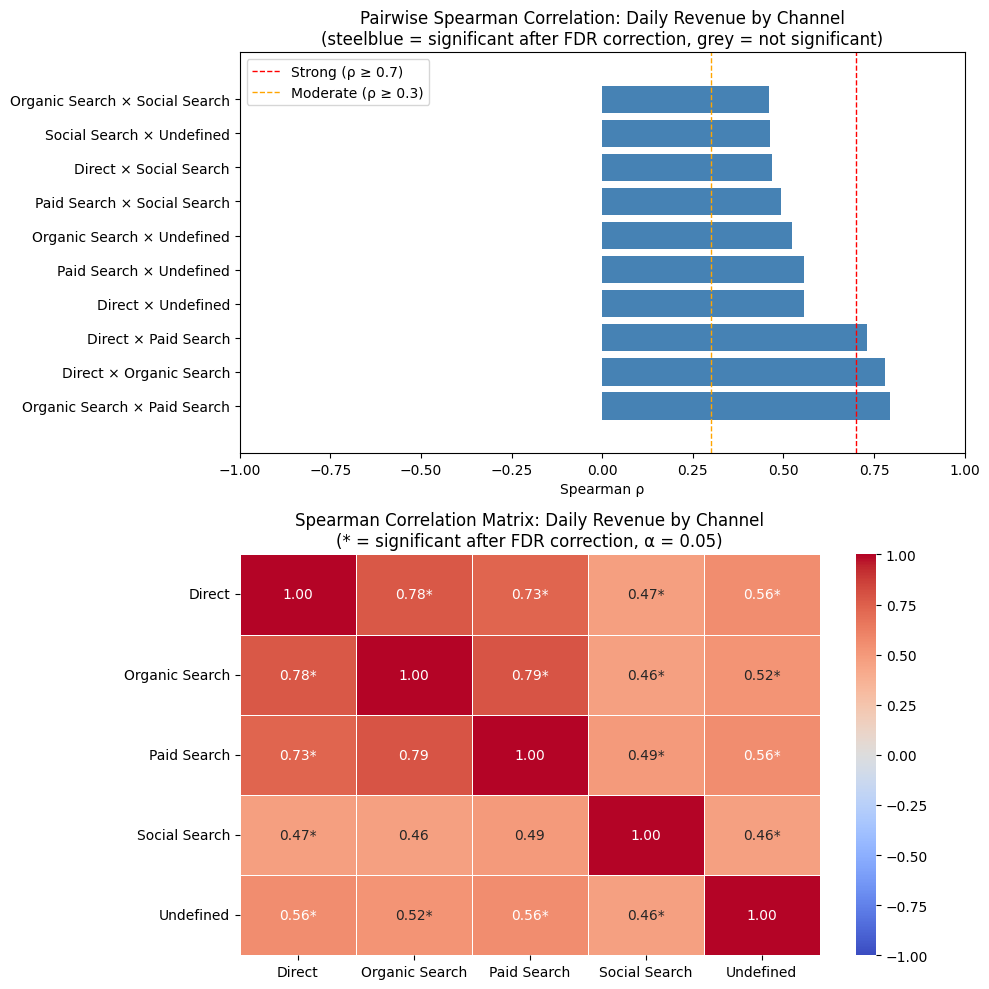

In [ ]:
# Do channels' daily revenue move together or independently,
# informing whether some external events influence traffic of different channels similarly or not?
daily_revenue_by_channel = (
    sales_df
    .groupby(['traffic_channel', 'session_and_order_date'])['product_price_per_item']
    .sum()
    .reset_index()
    .rename(columns={'product_price_per_item': 'revenue'})
)


daily_revenue_pivot = (
    daily_revenue_by_channel
    .pivot(index='session_and_order_date', columns='traffic_channel', values='revenue')
)
display(daily_revenue_pivot)
# Pairwise Spearman tests for channel correlation
channels = daily_revenue_pivot.columns.tolist()
results = []

for ch1, ch2 in combinations(channels, 2):
    rho, p_value = stats.spearmanr(daily_revenue_pivot[ch1], daily_revenue_pivot[ch2])
    results.append({
        'channel_1': ch1,
        'channel_2': ch2,
        'rho': rho,
        'p_value': p_value
    })

channel_corr_df = pd.DataFrame(results)

# FDR Correction (Benjamini-Hochberg)
# Takes all raw p-values together, ranks smallest to largest
# Each p-value compared to its own scaled threshold: (rank / total_tests) × alpha
# Controls expected proportion of false positives among significant results to 5%
# Less conservative than Bonferroni — reduces missed real effects (false negatives)
rejected, p_adjusted, _, _ = smt.multipletests(
    channel_corr_df['p_value'],
    alpha=0.05,
    method='fdr_bh'
)

channel_corr_df['p_adjusted'] = p_adjusted
channel_corr_df['significant'] = rejected
display("channel_corr_df", channel_corr_df)

def rho_strength(rho):
    rho = abs(rho)
    if rho >= 0.7:
        return 'strong'
    elif rho >= 0.3:
        return 'moderate'
    else:
        return 'weak'

channel_corr_df['effect_size'] = channel_corr_df['rho'].apply(rho_strength)
channel_corr_df = channel_corr_df.sort_values('rho', ascending=False).reset_index(drop=True)

corr_matrix = daily_revenue_pivot.corr(method='spearman')

# pivot significant column into matrix shape to mark FDR-corrected pairs with *
sig_matrix = channel_corr_df.pivot(
    index='channel_1', columns='channel_2', values='significant'
).fillna(False)

annot_matrix = pd.DataFrame(
    index=corr_matrix.index,
    columns=corr_matrix.columns,
    dtype=str
)

for row in corr_matrix.index:
    for col in corr_matrix.columns:
        val = f"{corr_matrix.loc[row, col]:.2f}"
        if row == col:
            annot_matrix.loc[row, col] = val
        elif row in sig_matrix.index and col in sig_matrix.columns:
            annot_matrix.loc[row, col] = f"{val}*" if sig_matrix.loc[row, col] else val
        elif col in sig_matrix.index and row in sig_matrix.columns:
            annot_matrix.loc[row, col] = f"{val}*" if sig_matrix.loc[col, row] else val
        else:
            annot_matrix.loc[row, col] = val


fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Chart 1 — bar chart of pairwise rho values
colors = ['steelblue' if sig else 'lightgrey' for sig in channel_corr_df['significant']]
pair_labels = channel_corr_df['channel_1'] + ' × ' + channel_corr_df['channel_2']

axes[0].barh(pair_labels, channel_corr_df['rho'], color=colors)
axes[0].axvline(x=0.7, color='red', linestyle='--', linewidth=1, label='Strong (ρ ≥ 0.7)')
axes[0].axvline(x=0.3, color='orange', linestyle='--', linewidth=1, label='Moderate (ρ ≥ 0.3)')
axes[0].set_xlabel('Spearman ρ')
axes[0].set_xlim(-1, 1)
axes[0].set_title('Pairwise Spearman Correlation: Daily Revenue by Channel\n(steelblue = significant after FDR correction, grey = not significant)')
axes[0].legend()
axes[0].margins(y=0.1)

# Chart 2 — heatmap with FDR significance marked by *
sns.heatmap(
    corr_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Spearman Correlation Matrix: Daily Revenue by Channel\n(* = significant after FDR correction, α = 0.05)')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Registration & Subscription Overview

**Business questions:** What share of our users are registered and subscribed — and does this distribution suggest registration and newsletter are reaching the right audience? How many of our users have verified their emails?

**Inference:**

**Registered users** represent 8% of total sessions and 8.3% of purchasing sessions — an identical distribution suggesting registration status does not affect purchase likelihood. This hypothesis is planned to be tested in the User Behavior section.

United States alone holds \~44% of registrations, while top 5 countries by registration are United States, Canada, India, United Kingdom and France (\~66% from total registrations).

**Newsletter subscription** is exclusive to registered users — unregistered sessions show 0% subscription rate, indicating subscription requires account registration by design.

Among **registered users**, **~83% remain actively subscribed**, ~17% have unsubscribed, suggesting strong newsletter retention among those who registered over the November 2020–January 2021 observation window.

Overall, **active subscribers represent ~6.6% of all sessions** - a figure suppressed by the dominant share of unregistered users who seemingly cannot subscribe, with **1.4% having previously unsubscribed**.
Whether newsletter subscribers generate more revenue than non-subscribers is planned to be analyzed in forthcoming sections of the analysis.

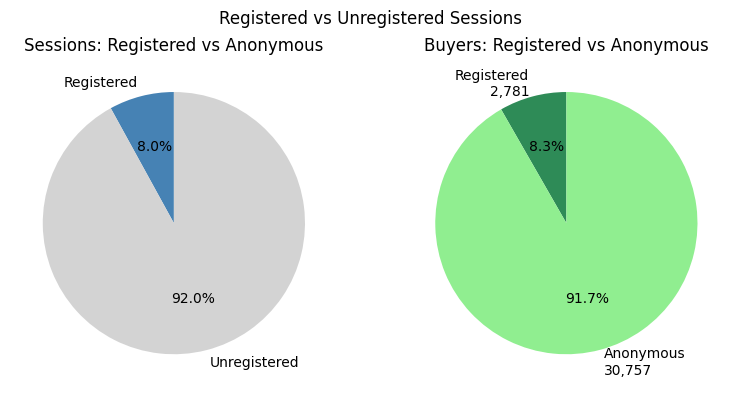

In [ ]:
registered_users = sales_df[sales_df['registered_account_id'].notna()]
unregistered_users = sales_df[sales_df['registered_account_id'].isna()]

figure, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].pie(x=[registered_users.shape[0], unregistered_users.shape[0]], labels=['Registered', 'Unregistered'], autopct='%1.1f%%', colors=['steelblue', 'lightgrey'], startangle=90)

axes[0].set_title('Sessions: Registered vs Anonymous')

axes[1].pie(
    [registered, anonymous],
    labels=[f'Registered\n{registered:,}', f'Anonymous\n{anonymous:,}'],
    colors=['seagreen', 'lightgreen'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Buyers: Registered vs Anonymous')

plt.suptitle('Registered vs Unregistered Sessions')

plt.tight_layout()
plt.show()

In [ ]:
def analyze_subscr(df):
    newsletter_dist = pd.DataFrame({
        'count': df['is_unsubscribed_from_newsletter'].value_counts(dropna=False),
        'pct': df['is_unsubscribed_from_newsletter'].value_counts(dropna=False, normalize=True) * 100
    })

    newsletter_dist.index = newsletter_dist.index.astype(str)
    newsletter_dist = newsletter_dist.rename(index={
        '0': 'subscribed',
        '1': 'unsubscribed',
        '<NA>': 'never_subscribed'
    })

    newsletter_dist['pct'] = newsletter_dist['pct'].round(2)
    newsletter_dist = newsletter_dist.reindex(
        ['subscribed', 'unsubscribed', 'never_subscribed'],
        fill_value=0
    )

    return newsletter_dist

total_split = analyze_subscr(sales_df)
registered_subscr_split = analyze_subscr(df=sales_df[sales_df['registered_account_id'].notna()])
unregistered_subscr_split = analyze_subscr(df=sales_df[sales_df['registered_account_id'].isna()])

display("total_split", total_split)
display("registered_subscr_split", registered_subscr_split)
display("unregistered_subscr_split", unregistered_subscr_split)

'total_split'

,count,pct
is_unsubscribed_from_newsletter,,
subscribed,23210,6.64
unsubscribed,4735,1.35
never_subscribed,321600,92.01


'registered_subscr_split'

,count,pct
is_unsubscribed_from_newsletter,,
subscribed,23210,83.06
unsubscribed,4735,16.94
never_subscribed,0,0.0


'unregistered_subscr_split'

,count,pct
is_unsubscribed_from_newsletter,,
subscribed,0,0.0
unsubscribed,0,0.0
never_subscribed,321600,100.0


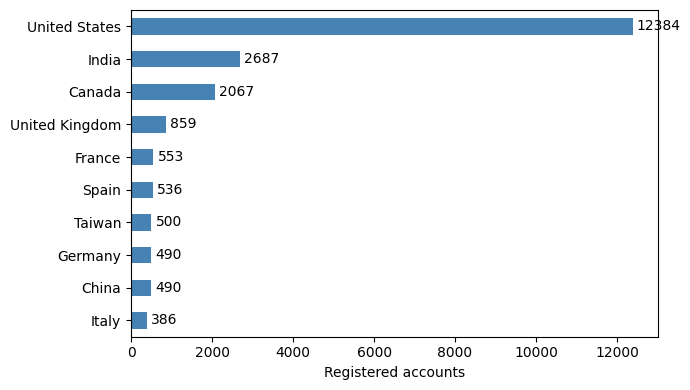

In [ ]:
top_countries_by_registration = sales_df[sales_df['registered_account_id'].notna()].groupby('country')['registered_account_id'].nunique().sort_values(ascending=False).head(10)

ax = top_countries_by_registration.sort_values().plot.barh(figsize=(7, 4), color='steelblue')
ax.bar_label(ax.containers[0], padding=3)
ax.set_xlabel('Registered accounts')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Email Verification

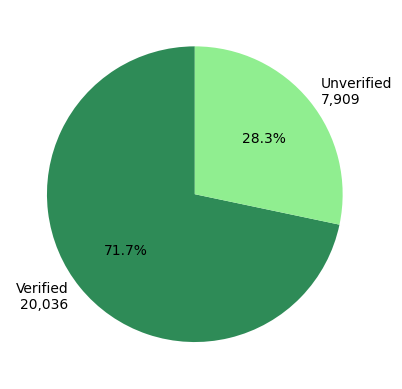

In [ ]:
email_verifications = registered_users['is_account_verified'].value_counts()
plt.pie(
    email_verifications,
    labels=[f'Verified\n{email_verifications[1]:,}', f'Unverified\n{email_verifications[0]:,}'],
    colors=['seagreen', 'lightgreen'],
    autopct='%1.1f%%',
    startangle=90,
)
plt.show()

# What Do Our Users Buy?

**Inference:**

**Top 10 revenue categories** are Sofas & armchairs, Chairs, Beds, Bookcases & shelving units, and Cabinets & cupboards, Otdoor furniture, Tables & Desks, Chests of drawers & drawer units, Bar furniture, Childern's furniture (98.4% of total store revenue).

Price distribution reveals 3 distinct positioning tiers:
* Sofas, Beds, Cabinets & Cupboards are **premium segments** — both show median item prices above the overall store median (\$445) with wide price ranges and significant high-value outliers.
* Chests of drawers & drawer units, Bar furniture perform as a **mid-range** category with median product price close to the median store product price.
* Chairs, Otdoor furniture, Tables & Desks, Bookcases & shelving units, Childern's furniture are low-range categories with below-median item prices. Though, the order volume in Bookcases & shelving units,Tables & Desks and Childern's furniture is higher than the revenue obtained from these categories.

**Category preferences are consistent across all top 5 revenue-generating countries and continents** — the same categories dominate in the US, India, Canada, UK, and France and on different continents, with no market requiring a locally differentiated category strategy.

**Daily order volume** across top categories shows strong-to-moderate positive correlation (ρ = 0.31–0.81, all FDR-corrected significant), confirming that **category demand moves together — driven by shared external factors** such as seasonal events and sitewide promotions.

Combined, these findings support a **unified global strategy:** one promotional calendar, coordinated inventory planning across correlated categories, and consistent category merchandising across all top markets.

## Top categories

**Business questions:** Which 10 product categories generate the most revenue and which 10 product categories have the biggest volume of orders?

**Inference:**

**Top 10 revenue categories** are Sofas & armchairs, Chairs, Beds, Bookcases & shelving units, and Cabinets & cupboards, Otdoor furniture, Tables & Desks, Chests of drawers & drawer units, Bar furniture, Childern's furniture (98.4% of total store revenue).

Price distribution reveals three distinct positioning tiers:
* Sofas, Beds, Cabinets & Cupboards are **premium segments** — both show median item prices above the overall store median (\$445) with wide price ranges and significant high-value outliers.
* Chests of drawers & drawer units, Bar furniture perform as a **mid-range** category with median product price close to the median store product price.
* Chairs, Otdoor furniture, Tables & Desks, Bookcases & shelving units, Childern's furniture are low-range categories with below-median item prices. Though, the order volume in Bookcases & shelving units,Tables & Desks and Childern's furniture is higher than the revenue obtained from these categories.

In [ ]:
category_revenue_share = sales_df.groupby('product_category')['product_price_per_item'].sum().sort_values(ascending=False).head(10)

top_10_revenue_share = category_revenue_share.sum() / sales_df['product_price_per_item'].sum() * 100
top_10_revenue_share

np.float64(98.44740030357629)

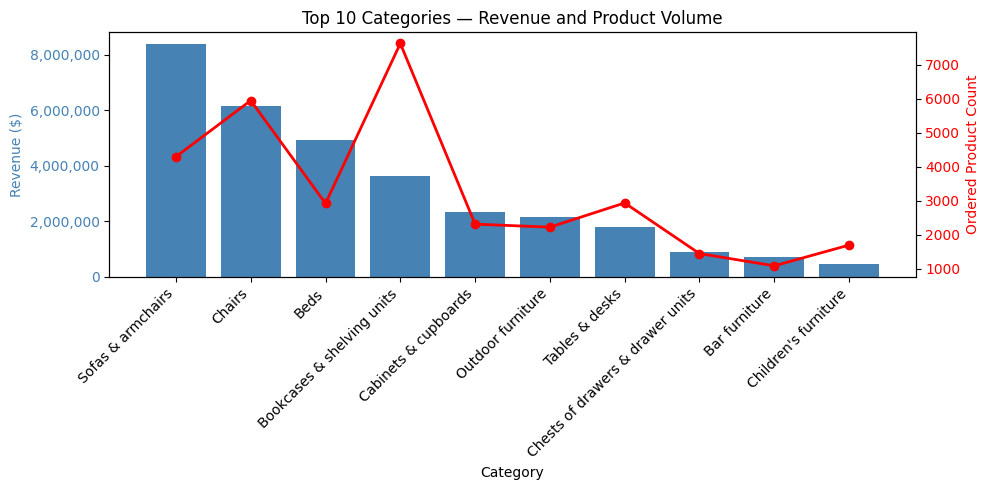

In [ ]:
cat_stats = sales_df.groupby('product_category').agg(ordered_product_cnt=('product_id', 'count'), revenue=('product_price_per_item', 'sum')).sort_values(by='revenue', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(cat_stats.index, cat_stats['revenue'], color='steelblue', label='Revenue')
ax1.set_ylabel('Revenue ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = ax1.twinx()  # second y-axis sharing the same x-axis
ax2.plot(cat_stats.index, cat_stats['ordered_product_cnt'], color='red', marker='o', linewidth=2, label='Product Count')
ax2.set_ylabel('Ordered Product Count', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xlabel('Category')
ax1.set_title('Top 10 Categories — Revenue and Product Volume')
ax1.set_xticks(range(len(cat_stats.index)))
ax1.set_xticklabels(cat_stats.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()


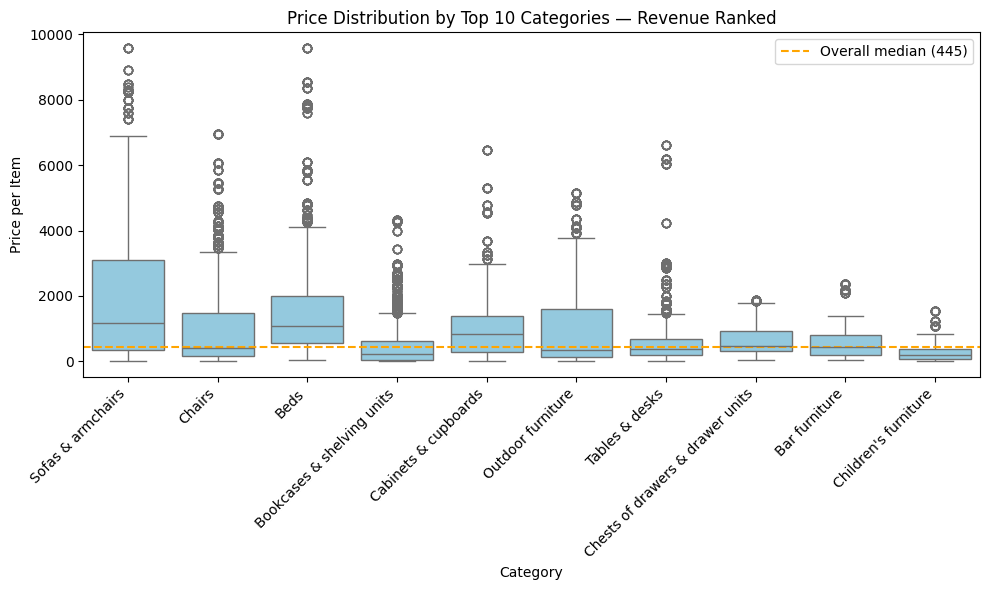

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

overall_median = sales_df['product_price_per_item'].median()
overall_mean = sales_df['product_price_per_item'].mean()

top_10_cats = cat_stats.index.tolist()
plot_df = sales_df[
    sales_df['product_category'].isin(top_10_cats) &
    sales_df['product_price_per_item'].notna()
]

order = (
    plot_df.groupby('product_category')['product_price_per_item']
    .sum()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=plot_df,
    x='product_category',
    y='product_price_per_item',
    order=order,
    color='skyblue',
    ax=ax
)

ax.axhline(y=overall_median, color='orange', linestyle='--', linewidth=1.5, label=f'Overall median ({overall_median:,.0f})')

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_title('Price Distribution by Top 10 Categories — Revenue Ranked')
ax.set_xlabel('Category')
ax.set_ylabel('Price per Item')
ax.legend()
plt.tight_layout()
plt.show()

## Category × Country

**Business questions:** Do the top categories globally maintain the same popularity in our top 5 revenue-generating countries, or do local market preferences differ? Should we have different inventory strategy for our top countries?

**Inference:**

Top 5 countries show consistent category preferences.

This suggests a unified inventory and marketing strategy is appropriate giving this data.

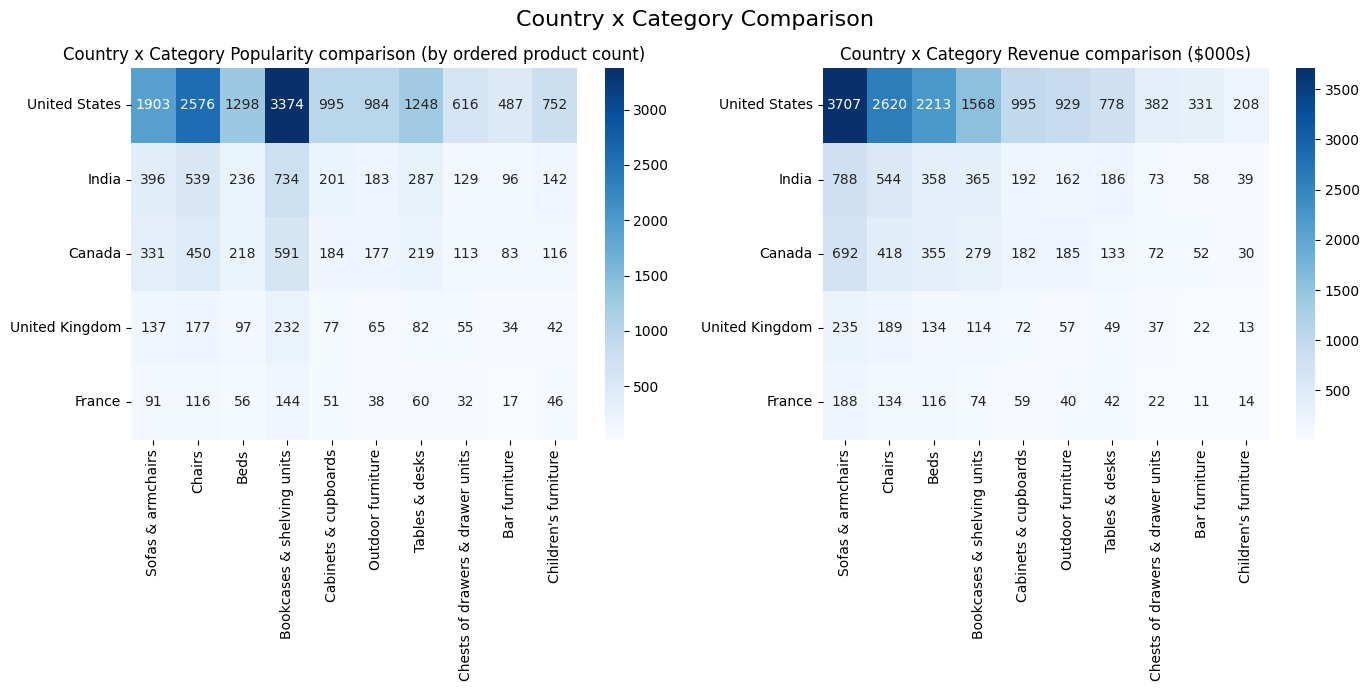

In [ ]:
# country x category comparison by popularity (product_id count)
def compare(df, dim1_index, dim2_column, metric, aggfunc, top_dim1=None, top_dim2=None):
  result_df = df.pivot_table(index=dim1_index, columns=dim2_column, values=metric, aggfunc=aggfunc, fill_value=0)

  if top_dim1 is None:
    top_dim1 = df.groupby(dim1_index)[metric].agg(aggfunc).sort_values(ascending=False).head(5).index.tolist()
  if top_dim2 is None:
    top_dim2 = df.groupby(dim2_column)[metric].agg(aggfunc).sort_values(ascending=False).head(5).index.tolist()

  return result_df.loc[top_dim1, top_dim2]

# define order for 2 heatmaps
top_countries = sales_df.groupby('country')['product_price_per_item'].sum().sort_values(ascending=False).head(5).index.tolist()
top_categories = sales_df.groupby('product_category')['product_price_per_item'].sum().sort_values(ascending=False).head(10).index.tolist()

pivot_by_orders = compare(sales_df, 'country', 'product_category', 'product_id', 'count', top_countries, top_categories)
pivot_by_revenue = compare(sales_df, 'country', 'product_category', 'product_price_per_item', 'sum', top_countries, top_categories)


figure, axes = plt.subplots(1, 2, figsize=(14, 7))
sns.heatmap(pivot_by_orders.astype('float'), annot=True, fmt='.0f', cmap='Blues', ax=axes[0])
axes[0].set_title('Country x Category Popularity comparison (by ordered product count)')
sns.heatmap((pivot_by_revenue / 1000).astype('float'), annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
axes[1].set_title('Country x Category Revenue comparison ($000s)')

axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
plt.suptitle('Country x Category Comparison', fontsize=16)
plt.tight_layout()
plt.show()



## Category x Continent

**Business questions:** Do the top categories globally maintain the same popularity in our top 5 revenue-generating countries, or do local market preferences differ? Should we have different inventory strategy for our top countries?

**Inference:**

Continents show consistent category preferences.

This suggests a unified inventory and marketing strategy is appropriate giving this data.

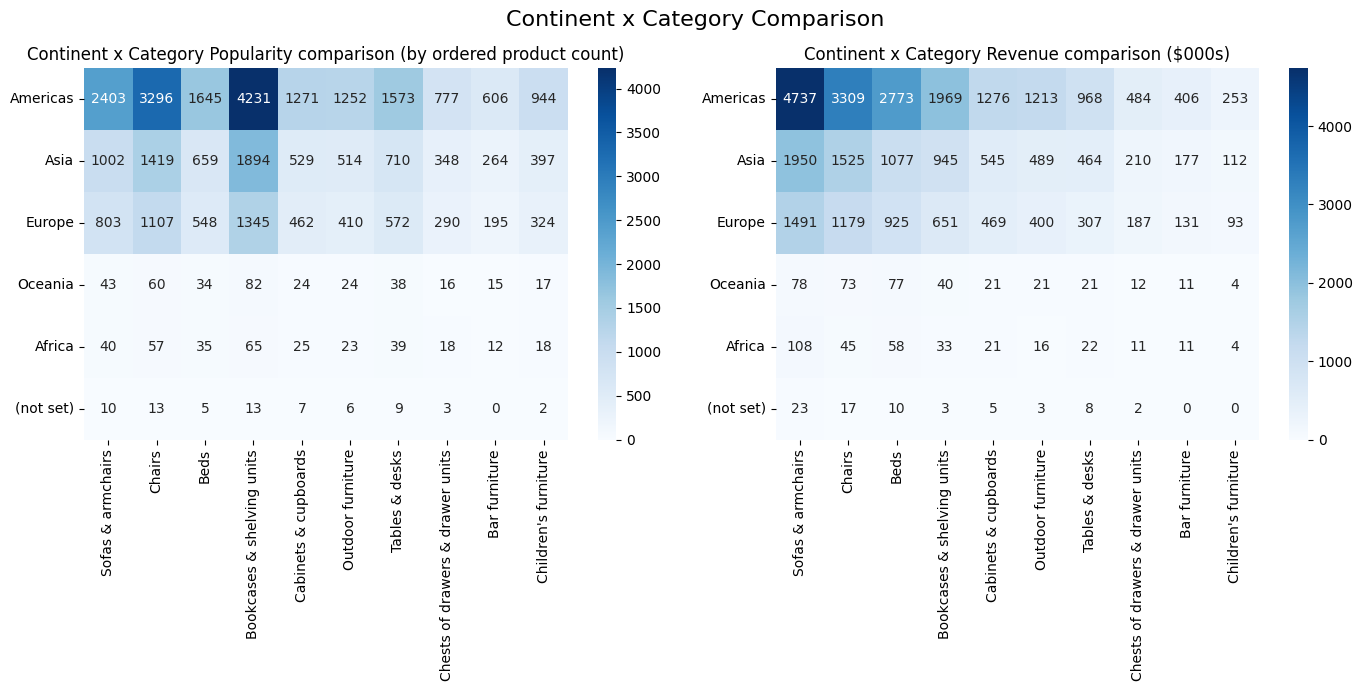

In [ ]:
# define order for 2 heatmaps
continents = sales_df.groupby('continent')['product_price_per_item'].sum().sort_values(ascending=False).index.tolist()
top_categories = sales_df.groupby('product_category')['product_price_per_item'].sum().sort_values(ascending=False).head(10).index.tolist()

pivot_by_orders = compare(sales_df, 'continent', 'product_category', 'product_id', 'count', continents, top_categories)
pivot_by_revenue = compare(sales_df, 'continent', 'product_category', 'product_price_per_item', 'sum', continents, top_categories)


figure, axes = plt.subplots(1, 2, figsize=(14, 7))
sns.heatmap(pivot_by_orders.astype('float'), annot=True, fmt='.0f', cmap='Blues', ax=axes[0])
axes[0].set_title('Continent x Category Popularity comparison (by ordered product count)')
sns.heatmap((pivot_by_revenue / 1000).astype('float'), annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
axes[1].set_title('Continent x Category Revenue comparison ($000s)')

axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
plt.suptitle('Continent x Category Comparison', fontsize=16)
plt.tight_layout()
plt.show()

## Category Correlations

**Business questions:** Do sales (daily purchased products) across our top 10 categories move together — and if one category declines, should we expect others to follow? This could inform us about user behaviour indicating whether customers tend to purchase across categories simultaneously (e.g. home furnishing occasions, holiday gifting) or whether each category serves independent purchase occasions.

**Inference:**

Daily order volume moves together across all top 10 categories. Every pair is positively correlated (ρ = 0.31–0.81, all significant after FDR correction); none is weak.

A tight core of five. Bookcases, Chairs, Sofas, Beds and Tables intercorrelate at ρ ≥ 0.68, producing all 8 strong pairs in the matrix. The strongest: Bookcases × Sofas (0.81) and Chairs × Sofas (0.80).

Bar furniture is the outlier, holding the weakest coefficient in most of its pairs (0.31 with Children's furniture).

**The direction is consistently positive across all pairs — when demand rises in one category, it tends to rise across others simultaneously given this dataset.**

**Caveat:** this analysis covers a holiday-heavy 3-month window (Nov 2020–Jan 2021). Correlations may be partially driven by seasonal effects rather than structural year-round comovement — validation against a full-year dataset is recommended before drawing permanent inventory strategy conclusions.

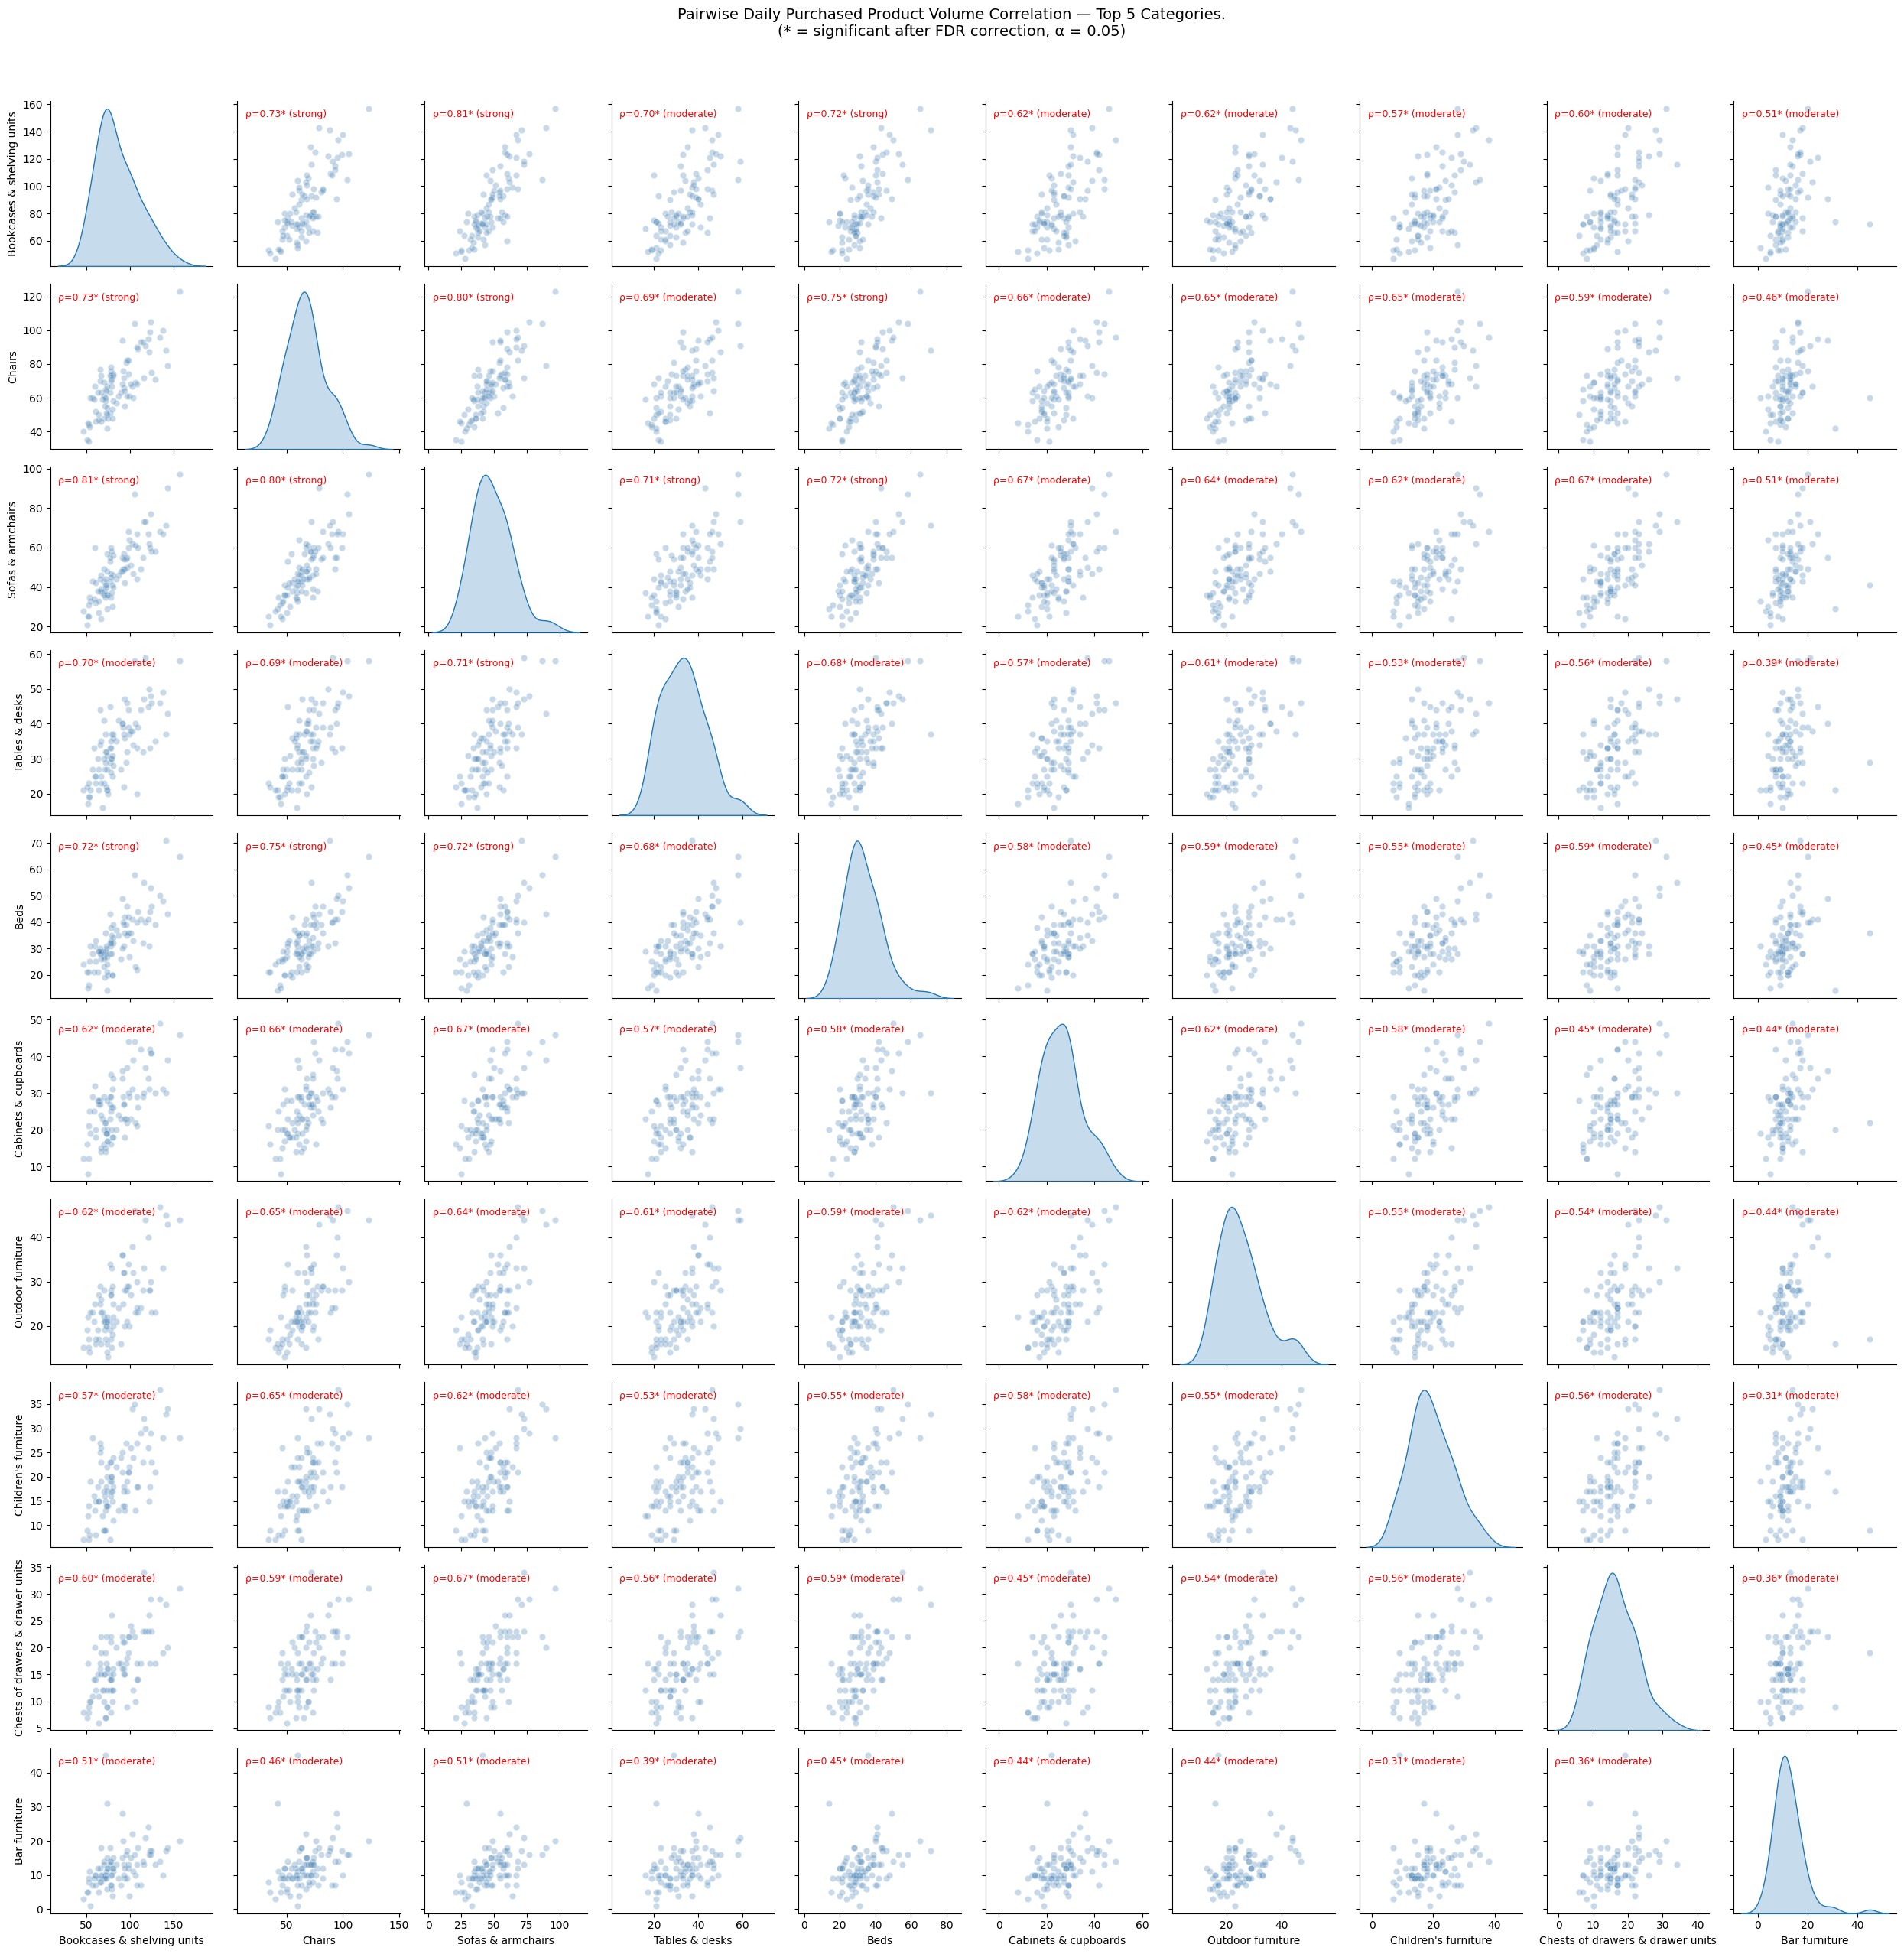

In [ ]:
# Pairwise Spearman correlation of daily order volume across top 10 categories by purchased items
# Goal: assess whether category demand moves together (shared external drivers) or independently (category-specific purchase occasions)
# Steps:
# 1. Identify top 10 categories by total order volume
# 2. Build daily order volume pivot (date × category)
# 3. Compute pairwise Spearman correlations for all category pairs
# 4. Apply FDR correction (Benjamini-Hochberg, α = 0.05) for multiple comparisons
# 5. Visualise as annotated pairplot

top_10_cat_by_orders = sales_df.groupby('product_category')['product_id'].count().rename('order_cnt').sort_values(ascending=False).reset_index().head(10)

cat_daily_orders = sales_df.pivot_table(index='session_and_order_date', columns='product_category', values='product_id', aggfunc='count')


top_10_cat_list = top_10_cat_by_orders['product_category'].tolist()
corr_result = []

for cat1, cat2 in combinations(top_10_cat_list, 2):
  rho, p_value = stats.spearmanr(cat_daily_orders[cat1], cat_daily_orders[cat2])

  corr_result.append({
      'category1': cat1,
      'category2': cat2,
      'rho': rho,
      'p_value': p_value
  })

corr_df = pd.DataFrame(corr_result)

# FDR Correction (Benjamini-Hochberg) of p_value
null_hypothesis_rejected, p_value_adjusted, _, _ = smt.multipletests(corr_df['p_value'], alpha=0.05, method='fdr_bh')

corr_df['significant'] = null_hypothesis_rejected
corr_df['p_value_adjusted'] = p_value_adjusted

corr_df['strength'] = corr_df['rho'].apply(rho_strength)

top_10_daily = cat_daily_orders[top_10_cat_list]

g = sns.pairplot(
    top_10_daily,
    kind='scatter',
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 'color': 'steelblue'},
)

# add rho annotation to each off-diagonal cell
for i, cat1 in enumerate(top_10_cat_list):
    for j, cat2 in enumerate(top_10_cat_list):
        if i != j:
            # find rho for this pair
            pair = corr_df[
                ((corr_df['category1'] == cat1) & (corr_df['category2'] == cat2)) |
                ((corr_df['category1'] == cat2) & (corr_df['category2'] == cat1))
            ]
            if len(pair) > 0:
                rho = pair['rho'].values[0]
                sig = pair['significant'].values[0]
                label = f"ρ={rho:.2f}{'*' if sig else ''} ({pair['strength'].values[0]})"
                g.axes[i][j].annotate(label, xy=(0.05, 0.9),
                                       xycoords='axes fraction', fontsize=9,
                                       color='red' if sig else 'grey')

plt.suptitle('Pairwise Daily Purchased Product Volume Correlation — Top 5 Categories.\n(* = significant after FDR correction, α = 0.05)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()



# Where Does Revenue Come From?

**Inference:**

**Revenue is concentrated but behaviorally uniform across markets.** The top 5 countries generate 65% of revenue, yet show no reliable difference in revenue per session — all country CIs overlap the store baseline. Revenue per session is a category story, not a country story.

Country revenue correlation is moderate-to-low (ρ = 0.13–0.56), and top-3 continent correlation is moderate (ρ = 0.61–0.67) supporting a **unified global promotion calendar as a baseline — shared demand drivers affect all markets**. India with other countries, France and United Kingdom show the weakest correlation and could benefit from localized promotional timing as a stretch goal, though given they generate the least revenue among the top 5, this is only justified if the effort does not exceed the benefit — worth exploring only if resources allow. For continents the strongest pair is America x Asia (ρ = 0.67).

**Categories**, by contrast, **show both stronger comovement and bigger variance**. Daily order correlation is moderate-strong (ρ = 0.31–0.81) with clear tiers:

* **Premium** — Sofas & armchairs (\$1,176), Beds (\$1,095), Cabinets & cupboards (\$841). All sit far above the store median (\$445) with CIs that clear it by a wide margin.
* **At baseline** — Bar furniture (\$435) and Chests of drawers (\$460) are the only categories whose CIs overlap the store median; they define the store's price centre.
* **Budget** — Children's furniture (\$195), Bookcases & shelving units (\$235), Outdoor furniture (\$356), Tables & desks (\$376), Chairs (\$395). All reliably below baseline.

## Market Correlations & Diversification

**Business questions:** Do revenue trends move together across our top markets — and if one region declines, should we expect a global impact or is our revenue risk geographically diversified?

**Inference:**

Daily revenue correlation across top 5 countries is **weak-moderate** for most pairs (ρ = 0.13–0.56, all FDR-corrected significant apart from France-UK pair where weak correlation is spotted but the result is not statistically significant), with **France × United Kingdom showing the weakest relationship (ρ = 0.13) — market synchtonization is not confirmed**.

Daily revenue correlation across top 3 continents is **moderate** for all pairs (ρ = 0.61–0.67)

This contrasts with category-level order correlation (ρ = 0.31–0.81) which larger variance was observed — some category pair demand synchronizes more tightly than market demand.

The strongest pair is US × Canada (ρ = 0.56), consistent with geographic proximity and shared cultural and economic calendar. While for continents - the strongest pair is America x Asia (ρ = 0.67).

**Business implication:** a unified global promotion calendar is appropriate as a baseline. However, moderate rather than strong correlation justifies local tactical timing adjustments per market. Risk is meaningfully diversified — a demand shock in one market does not uniformly propagate to all others given this data.

**Data note:** Jan 28–31 2021 show zero revenue across all countries. These days were retained in the correlation analysis as zero-revenue observations but should be verified for further decisions.

Suspicious days:  session_and_order_date
2021-01-31         0.0
2021-01-30         0.0
2021-01-29         0.0
2021-01-28         0.0
2020-11-07    103402.7
dtype: float64
2021-01-28: total_sessions=0, total_revenue=0.0
2021-01-29: total_sessions=0, total_revenue=0.0
2021-01-30: total_sessions=0, total_revenue=0.0
2021-01-31: total_sessions=0, total_revenue=0.0


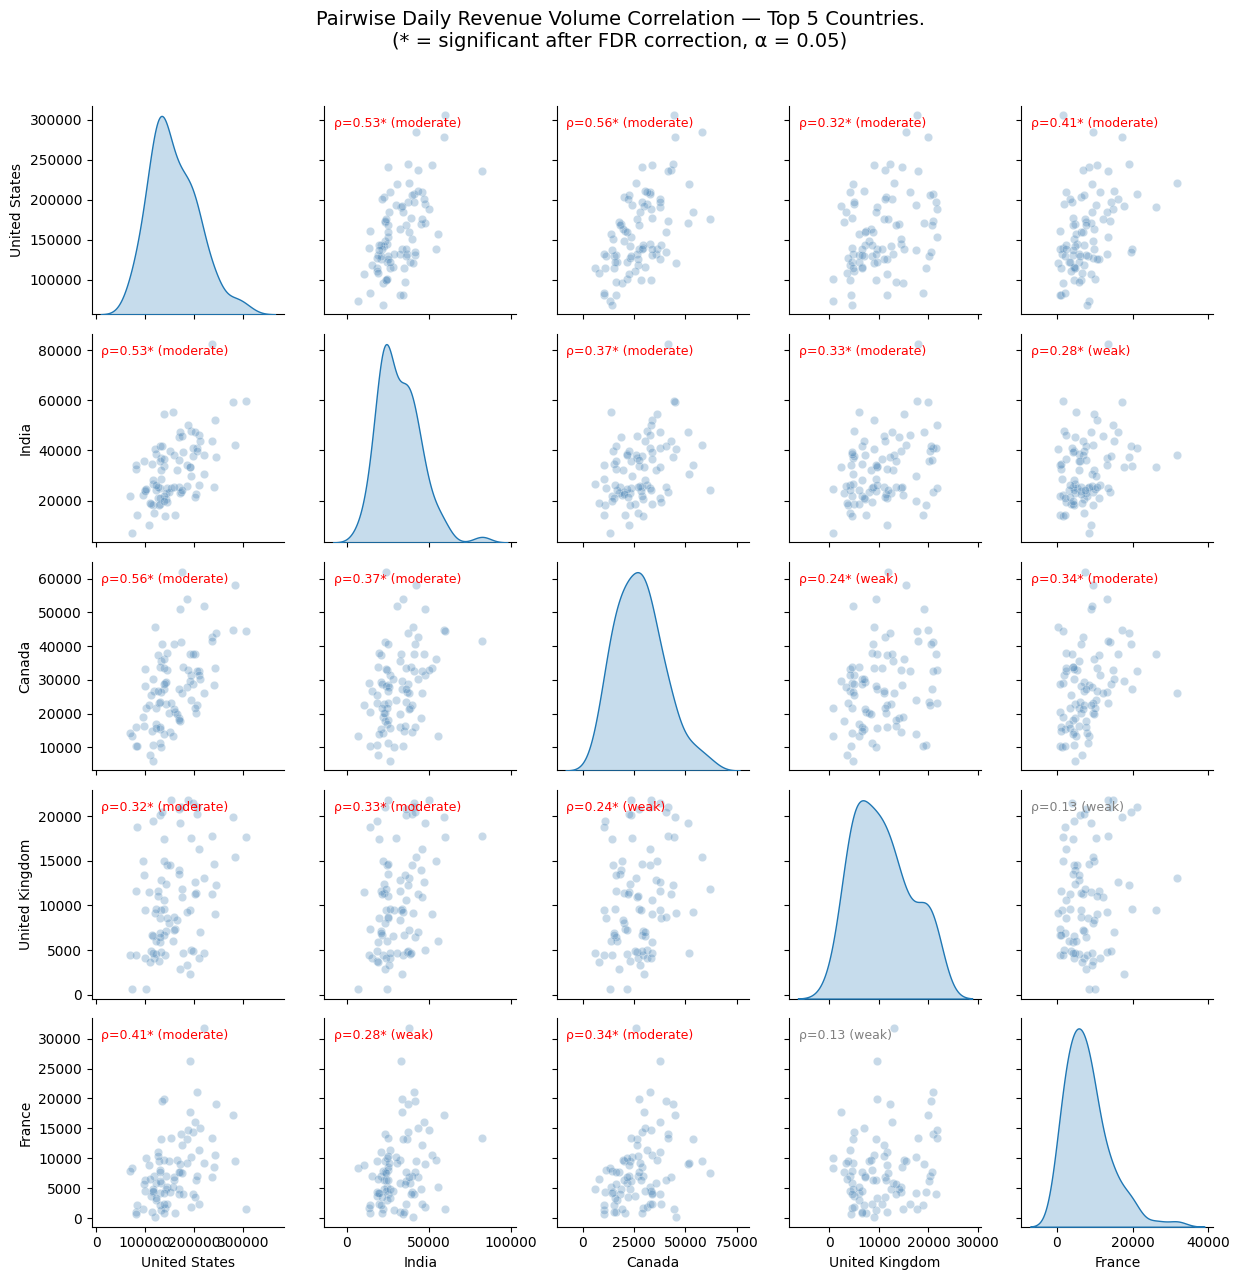

In [ ]:
# Pairwise Spearman correlation of daily revenue volume across top 5 countries by revenue
# Goal: assess whether country revenue moves together (shared external drivers) or independently (country-specific revenue movements). Account for the fact that holidays across top countries differ, so some global unifying factor could be at play if correlation is strong among all countries
# Steps:
# 1. Identify top 5 countries by total revenue
# 2. Build daily revenue volume pivot (date × country)
# 3. Compute pairwise Spearman correlations for all country pairs
# 4. Apply FDR correction (Benjamini-Hochberg, α = 0.05) for multiple comparisons
# 5. Visualise as annotated pairplot

top_5_countries_by_revenue = sales_df.groupby('country')['product_price_per_item'].sum().rename('revenue').sort_values(ascending=False).reset_index().head(5)
# top_5_countries_by_revenue
country_daily_revenue = sales_df.pivot_table(index='session_and_order_date', columns='country', values='product_price_per_item', aggfunc='sum')
# country_daily_revenue
top_5_country_list = top_5_countries_by_revenue['country'].tolist()

# check suspicious days with zero revenue
daily_revenue_by_country = country_daily_revenue[top_5_country_list]
print("Suspicious days: ", daily_revenue_by_country.sum(axis=1).sort_values().head(5))
suspicious_dates = ['2021-01-28', '2021-01-29', '2021-01-30', '2021-01-31']
for date in suspicious_dates:
    all_revenue = sales_df[sales_df['session_and_order_date'] == date]['product_price_per_item'].sum()
    all_sessions = sales_df[sales_df['session_and_order_date'] == date]['session_id'].nunique()
    print(f"{date}: total_sessions={all_sessions}, total_revenue={all_revenue}")

# exclude trailing zero-revenue days
valid_dates = country_daily_revenue[
    country_daily_revenue[top_5_country_list].sum(axis=1) > 0
].index
country_daily_revenue_clean = country_daily_revenue.loc[valid_dates]
top_5_daily = country_daily_revenue_clean[top_5_country_list]


corr_result = []
# top_5_country_list
for country1, country2 in combinations(top_5_country_list, 2):
  rho, p_value = stats.spearmanr(top_5_daily[country1], top_5_daily[country2])

  corr_result.append({
      'country1': country1,
      'country2': country2,
      'rho': rho,
      'p_value': p_value
  })

corr_df = pd.DataFrame(corr_result)

# FDR Correction (Benjamini-Hochberg)
null_hypothesis_rejected, p_value_adjusted, _, _ = smt.multipletests(corr_df['p_value'], alpha=0.05, method='fdr_bh')

corr_df['significant'] = null_hypothesis_rejected
corr_df['p_value_adjusted'] = p_value_adjusted

def rho_strength(rho):
  if rho >= 0.7:
    return 'strong'
  elif rho >= 0.3:
    return 'moderate'
  else:
    return 'weak'

corr_df['strength'] = corr_df['rho'].apply(rho_strength)

g = sns.pairplot(
    top_5_daily,
    kind='scatter',
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 'color': 'steelblue'},
)

# add rho annotation to each off-diagonal cell
for i, country1 in enumerate(top_5_country_list):
    for j, country2 in enumerate(top_5_country_list):
        if i != j:
            pair = corr_df[
                ((corr_df['country1'] == country1) & (corr_df['country2'] == country2)) |
                ((corr_df['country1'] == country2) & (corr_df['country2'] == country1))
            ]
            if len(pair) > 0:
                rho = pair['rho'].values[0]
                sig = pair['significant'].values[0]
                label = f"ρ={rho:.2f}{'*' if sig else ''} ({pair['strength'].values[0]})"
                g.axes[i][j].annotate(label, xy=(0.05, 0.9),
                                       xycoords='axes fraction', fontsize=9,
                                       color='red' if sig else 'grey')

plt.suptitle('Pairwise Daily Revenue Volume Correlation — Top 5 Countries.\n(* = significant after FDR correction, α = 0.05)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()



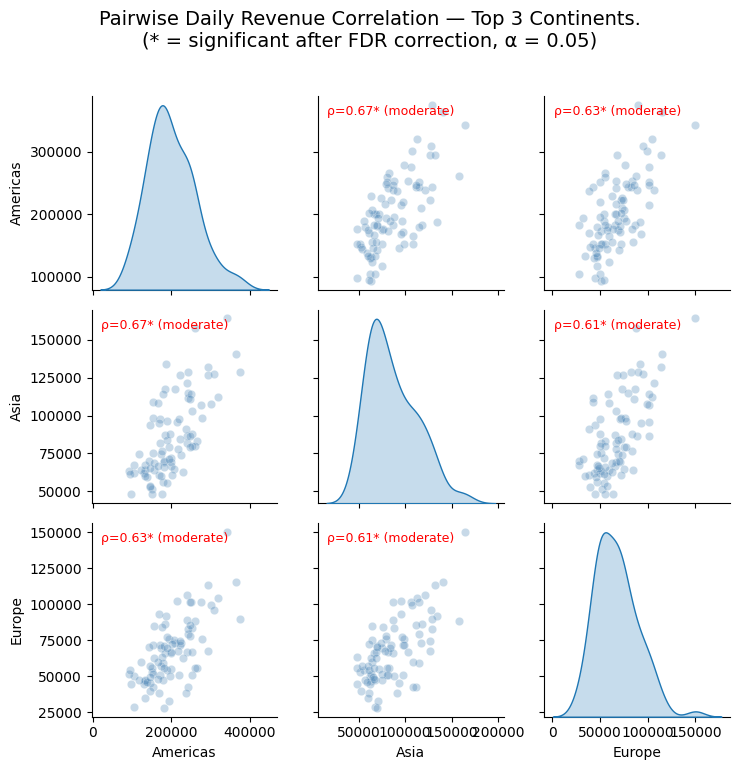

In [ ]:
# Pairwise Spearman correlation of daily revenue across top 3 continents by revenue
top_3_continents_by_revenue = (sales_df.groupby('continent')['product_price_per_item'].sum()
                               .rename('revenue').sort_values(ascending=False)
                               .reset_index().head(3))

continent_daily_revenue = sales_df.pivot_table(
    index='session_and_order_date', columns='continent',
    values='product_price_per_item', aggfunc='sum')

top_3_continent_list = top_3_continents_by_revenue['continent'].tolist()

# exclude trailing zero-revenue days (same artefact as in the country analysis)
valid_dates = continent_daily_revenue[
    continent_daily_revenue[top_3_continent_list].sum(axis=1) > 0
].index
top_3_daily = continent_daily_revenue.loc[valid_dates, top_3_continent_list]

corr_result = []
for c1, c2 in combinations(top_3_continent_list, 2):
    rho, p_value = stats.spearmanr(top_3_daily[c1], top_3_daily[c2])
    corr_result.append({'dim1': c1, 'dim2': c2, 'rho': rho, 'p_value': p_value})

corr_df = pd.DataFrame(corr_result)

rejected, p_adj, _, _ = smt.multipletests(corr_df['p_value'], alpha=0.05, method='fdr_bh')
corr_df['significant'] = rejected
corr_df['p_value_adjusted'] = p_adj
corr_df['strength'] = corr_df['rho'].apply(rho_strength)

g = sns.pairplot(top_3_daily, kind='scatter', diag_kind='kde',
                 plot_kws={'alpha': 0.3, 'color': 'steelblue'})

for i, c1 in enumerate(top_3_continent_list):
    for j, c2 in enumerate(top_3_continent_list):
        if i == j:
            continue
        pair = corr_df[((corr_df['dim1'] == c1) & (corr_df['dim2'] == c2)) |
                       ((corr_df['dim1'] == c2) & (corr_df['dim2'] == c1))]
        if len(pair):
            rho = pair['rho'].values[0]
            sig = pair['significant'].values[0]
            label = f"ρ={rho:.2f}{'*' if sig else ''} ({pair['strength'].values[0]})"
            g.axes[i][j].annotate(label, xy=(0.05, 0.9), xycoords='axes fraction',
                                  fontsize=9, color='red' if sig else 'grey')

plt.suptitle('Pairwise Daily Revenue Correlation — Top 3 Continents.\n'
             '(* = significant after FDR correction, α = 0.05)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Median Product Price Analysis with Bootstrap CI

**Business questions:** What is the average revenue per session across categories, countries — and which estimates are reliable enough to act on versus which require more data?

**Inference:**

> Median is used throughout — price distributions are right-skewed, so the mean would track a small number of high-ticket items rather than the typical product.

Category price tiers are sharply separated:

* **Premium** — Sofas & armchairs (\$1,176), Beds (\$1,095), Cabinets & cupboards (\$841). All sit far above the store median (\$445) with CIs that clear it by a wide margin.
* **At baseline** — Bar furniture (\$435) and Chests of drawers (\$460) are the only categories whose CIs overlap the store median; they define the store's price centre.
* **Budget** — Children's furniture (\$195), Bookcases & shelving units (\$235), Outdoor furniture (\$356), Tables & desks (\$376), Chairs (\$395). All reliably below baseline.

CIs are narrow relative to their medians throughout (widest is Cabinets at ±9%), so these rankings are precise, not artefacts of sample size.

In [ ]:
def calc_median_ci(df, metric, group_col, n_bootstrap=1000, ci=0.95, seed=42):
    """
    Median + bootstrap CI per group and overall (TOTAL).
    Uses purchase rows only (dropna on metric).
    Returns df: group, n, median, ci_lower, ci_upper, ci_width, overlaps_total
    """
    np.random.seed(42)
    alpha = 1 - ci
    results = []

    # overall baseline
    overall = df[metric].dropna().values
    boot = [np.median(np.random.choice(overall, len(overall), replace=True)) for _ in range(n_bootstrap)]
    results.append({
        'group': 'TOTAL',
        'n': len(overall),
        'median': np.median(overall),
        'ci_lower': np.percentile(boot, alpha / 2 * 100),
        'ci_upper': np.percentile(boot, (1 - alpha / 2) * 100),
    })

    # per group
    for group, g in df.groupby(group_col):
        values = g[metric].dropna().values
        if len(values) < 30:
            continue
        boot = [np.median(np.random.choice(values, len(values), replace=True)) for _ in range(n_bootstrap)]
        results.append({
            'group': group,
            'n': len(values),
            'median': np.median(values),
            'ci_lower': np.percentile(boot, alpha / 2 * 100),
            'ci_upper': np.percentile(boot, (1 - alpha / 2) * 100),
        })

    out = pd.DataFrame(results)
    out['ci_width'] = out['ci_upper'] - out['ci_lower']
    t_low = out.loc[out['group'] == 'TOTAL', 'ci_lower'].values[0]
    t_high = out.loc[out['group'] == 'TOTAL', 'ci_upper'].values[0]
    out['overlaps_total'] = (out['ci_lower'] <= t_high) & (out['ci_upper'] >= t_low)
    return out.sort_values('median', ascending=False).reset_index(drop=True)


def run_stat_tests(df, metric, group_col, top_groups=None):
    """
    Kruskal-Wallis across groups + one-sample Wilcoxon per group vs overall median.
    FDR-corrected. Uses purchase rows only.
    Returns wilcoxon df; prints Kruskal-Wallis result.
    """
    if top_groups is not None:
        df = df[df[group_col].isin(top_groups)]

    overall_median = df[metric].dropna().median()
    group_data = [(name, g[metric].dropna().values) for name, g in df.groupby(group_col) if len(g[metric].dropna()) >= 30]
    names, groups = zip(*group_data)

    k_stat, k_p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis: statistic={k_stat:.4f}, p={k_p:.4f}, significant={k_p < 0.05}")

    rows, pvals = [], []
    for name, values in zip(names, groups):
        diff = values - overall_median
        if np.all(diff == 0):
            continue
        _, p = stats.wilcoxon(diff)
        rows.append({
            'group': name,
            'n': len(values),
            'group_median': round(np.median(values), 2),
            'overall_median': round(overall_median, 2),
            'difference': round(np.median(values) - overall_median, 2),
            'p_raw': p,
        })
        pvals.append(p)

    out = pd.DataFrame(rows)
    _, p_adj, _, _ = smt.multipletests(pvals, alpha=0.05, method='fdr_bh')
    out['p_adjusted'] = p_adj
    out['significant'] = out['p_adjusted'] < 0.05
    return out.sort_values('difference', ascending=False).reset_index(drop=True)


def plot_ci_comparison(ci_df, title='Median Revenue per Session with 95% Bootstrap CI'):
    """
    Horizontal CI plot: each group's median + CI vs TOTAL baseline band.
    Grey = overlaps total (unreliable difference), blue = does not overlap (reliable).
    """
    total = ci_df[ci_df['group'] == 'TOTAL'].iloc[0]
    groups = ci_df[ci_df['group'] != 'TOTAL'].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, max(5, len(groups) * 0.7 + 2)))

    ax.axvspan(total['ci_lower'], total['ci_upper'], alpha=0.15, color='steelblue',
               label=f"Total CI [{total['ci_lower']:.0f}–{total['ci_upper']:.0f}]")
    ax.axvline(total['median'], color='steelblue', linestyle='--', linewidth=1.5,
               label=f"Total median ({total['median']:.0f})")

    for i, row in groups.iterrows():
        color = 'lightgrey' if row['overlaps_total'] else 'steelblue'
        ax.plot([row['ci_lower'], row['ci_upper']], [i, i], color=color, linewidth=3, solid_capstyle='round')
        ax.scatter(row['median'], i, color=color, zorder=5, s=60)
        ax.text(row['ci_upper'] + 1, i, f"{row['median']:.0f} [{row['ci_lower']:.0f}–{row['ci_upper']:.0f}]",
                va='center', fontsize=9)

    ax.set_yticks(range(len(groups)))
    ax.set_yticklabels(groups['group'])
    ax.set_xlabel('Median Category Product Price')
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()

Kruskal-Wallis: statistic=5408.1615, p=0.0000, significant=True


,group,n,group_median,overall_median,difference,p_raw,p_adjusted,significant
0,Sofas & armchairs,4301,1176.0,445.0,731.0,0.000000e+00,0.000000e+00,True
1,Beds,2926,1095.0,445.0,650.0,0.000000e+00,0.000000e+00,True
3,Cabinets & cupboards,2318,841.0,445.0,396.0,2.957356e-145,1.035075e-144,True
5,Chests of drawers & drawer units,1452,460.0,445.0,15.0,5.407963e-29,1.081593e-28,True
6,Bar furniture,1092,435.0,445.0,-10.0,7.364886e-08,8.592367e-08,True
7,Chairs,5952,395.0,445.0,-50.0,1.526381e-85,4.273868e-85,True
8,Tables & desks,2941,376.0,445.0,-69.0,2.244912e-01,2.244912e-01,False
9,Outdoor furniture,2229,356.0,445.0,-89.0,3.391415e-10,4.747980e-10,True
12,Bookcases & shelving units,7630,235.0,445.0,-210.0,6.225210e-39,1.452549e-38,True
13,Children's furniture,1702,195.0,445.0,-250.0,1.999586e-146,9.331403e-146,True


,group,n,median,ci_lower,ci_upper,ci_width,overlaps_total
0,Sofas & armchairs,4301,1176.0,1100.0,1250.0,150.0,False
1,Beds,2926,1095.0,1092.0,1145.0,53.0,False
3,Cabinets & cupboards,2318,841.0,777.0,925.0,148.0,False
5,Chests of drawers & drawer units,1452,460.0,445.0,495.0,50.0,True
6,TOTAL,33538,445.0,440.0,450.0,10.0,True
7,Bar furniture,1092,435.0,395.0,445.0,50.0,True
8,Chairs,5952,395.0,385.0,425.0,40.0,False
9,Tables & desks,2941,376.0,356.0,395.0,39.0,False
10,Outdoor furniture,2229,356.0,340.0,385.0,45.0,False
13,Bookcases & shelving units,7630,235.0,225.0,250.0,25.0,False


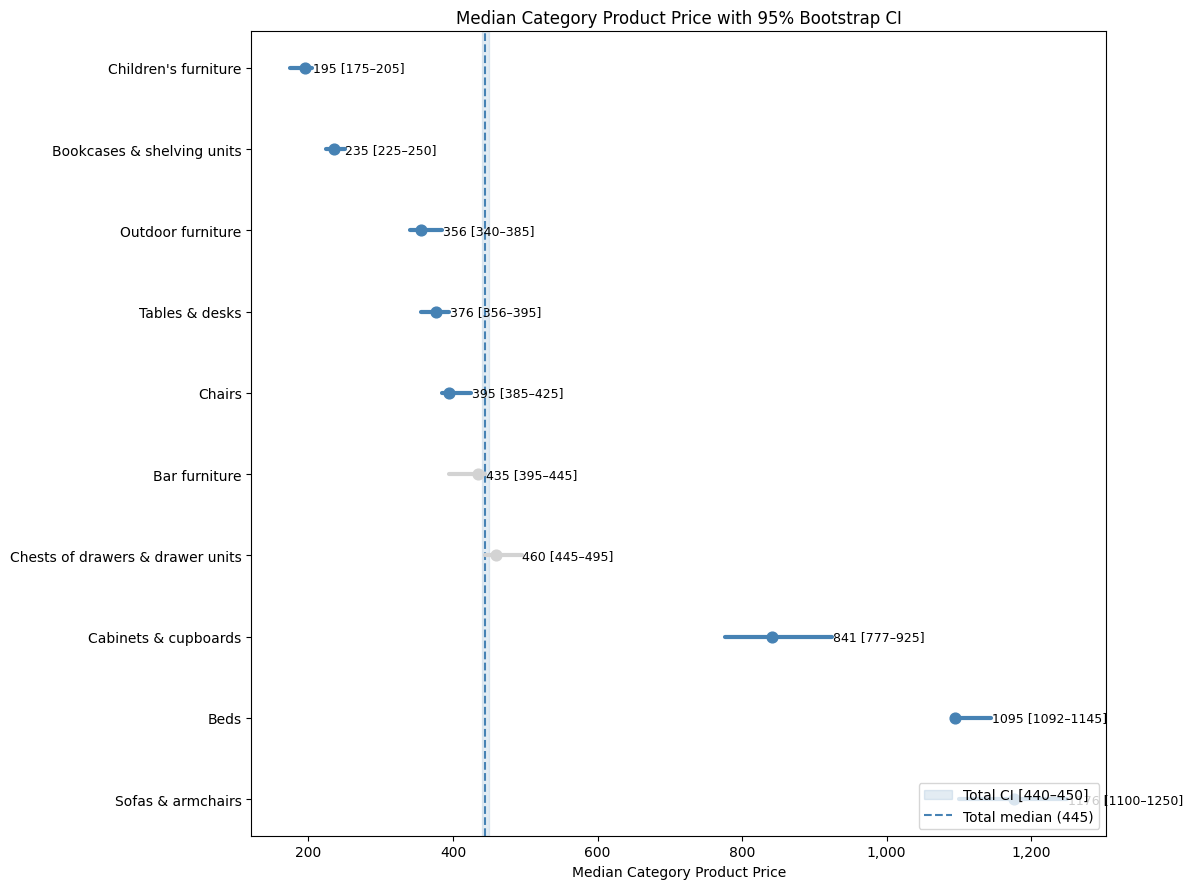

In [ ]:
top_10_categories_by_revenue = sales_df.groupby('product_category')['product_price_per_item'].agg('sum').sort_values(ascending=False).head(10).index.tolist()

category_median_diff = run_stat_tests(sales_df, 'product_price_per_item', 'product_category')
cat_median_diff_filtered = category_median_diff[category_median_diff['group'].isin(top_10_categories_by_revenue + ['TOTAL'])]

display(cat_median_diff_filtered)

category_median_ci = calc_median_ci(sales_df, 'product_price_per_item', 'product_category')

# filtered datasets
cat_filtered_median_ci = category_median_ci[category_median_ci['group'].isin(top_10_categories_by_revenue + ['TOTAL'])]

display(cat_filtered_median_ci)


plot_ci_comparison(cat_filtered_median_ci, title='Median Category Product Price with 95% Bootstrap CI')

Kruskal-Wallis: statistic=51.1895, p=0.7553, significant=False


,group,n,group_median,overall_median,difference,p_raw,p_adjusted,significant
13,France,678,497.5,445.0,52.5,2.809941e-15,4.214911e-14,True
35,United Kingdom,1029,445.0,445.0,0.0,3.374463e-11,4.049356e-10,True
36,Canada,2560,445.0,445.0,0.0,2.162685e-28,4.325370e-27,True
38,United States,14673,440.0,445.0,-5.0,1.362130e-157,8.172781e-156,True
46,India,3029,420.0,445.0,-25.0,9.709365e-33,2.912809e-31,True


,group,n,median,ci_lower,ci_upper,ci_width,overlaps_total
13,France,678,497.5,440.0,584.0125,144.0125,True
36,United Kingdom,1029,445.0,399.0,495.0000,96.0000,True
37,Canada,2560,445.0,399.0,475.0000,76.0000,True
38,TOTAL,33538,445.0,440.0,450.0000,10.0000,True
39,United States,14673,440.0,420.0,450.0000,30.0000,True
47,India,3029,420.0,395.0,445.0000,50.0000,True


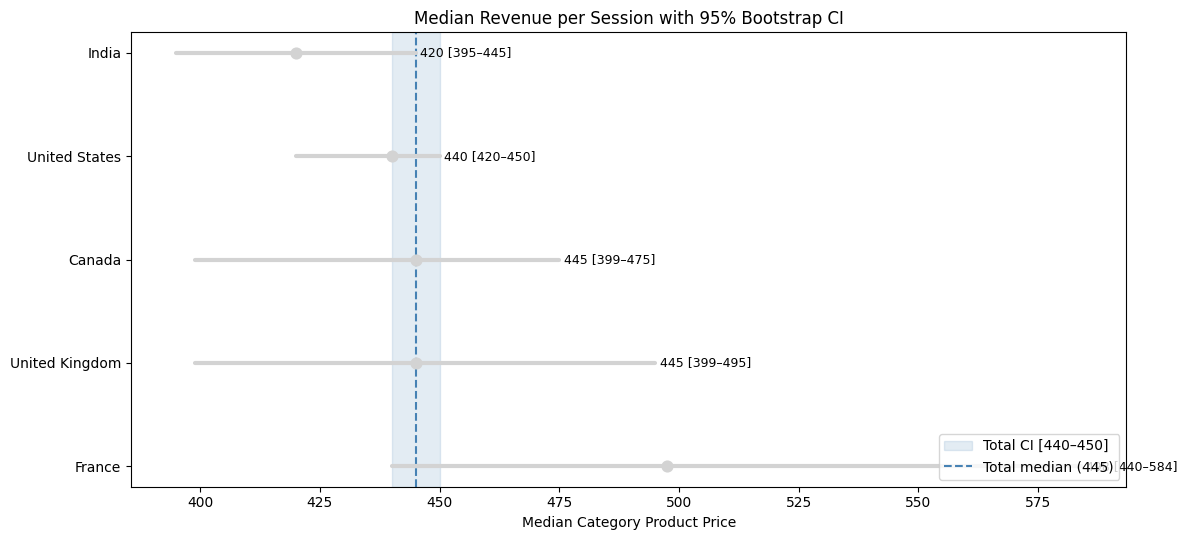

In [ ]:
top_5_countries_by_revenue = sales_df.groupby('country')['product_price_per_item'].agg('sum').sort_values(ascending=False).head(5).index.tolist()

country_median_diff = run_stat_tests(sales_df, 'product_price_per_item', 'country')
country_median_diff_filtered = country_median_diff[country_median_diff['group'].isin(top_5_countries_by_revenue + ['TOTAL'])]

display(country_median_diff_filtered)

country_median_ci = calc_median_ci(sales_df, 'product_price_per_item', 'country')

# filtered datasets
country_filtered_median_ci = country_median_ci[country_median_ci['group'].isin(top_5_countries_by_revenue + ['TOTAL'])]

display(country_filtered_median_ci)


plot_ci_comparison(country_filtered_median_ci)

# Do Registered Users Behave Differently?

**Inference:**

**Registered users does not behave differently.** Registered users' session share (8%) and purchase share (8.3%) are nearly identical, and revenue per session differs by only ~\$1 (\$92.41 vs \$91.38). The Mann-Whitney U test marks this as significant (p = 0.047), but with a large sample the test detects even trivial differences — the gap is statistically real but practically negligible. Optimization efforts can be applied uniformly, without segmenting by registration status.



Within the registered base, however, RFM analysis reveals the following structure: every customer bought exactly once (frequency drops out), and the uncorrelated recency and monetary dimensions define four segments — Champions, Stale big spenders, Recent budget buyers, and Hibernating. [Vizualization here.]('https://colab.research.google.com/drive/1WlOaOqaQ0uTiPvQklpae3bu9_GhicXsA#scrollTo=JyC1g0kQonjg&line=3&uniqifier=1')

**Caveat:** Findings are exploratory given the 3-month window; a 12-month view is needed to validate segments and observe repeat purchases.


## Registered vs Unregistered

**Business questions:** Who brings more revenue and higher revenue per session — registered or unregistered users — and is this difference statistically confirmed?

**Inference:**
This confirms the hypothesis raised in the Registration & Subscription Overview section — where registered users' near-identical session share (8%) and purchase share (8.3%) suggested registration status does not affect purchase likelihood.

The revenue per session comparison supports this in this dataset. Registered users generate higher revenue per session (\$92.41 vs \$91.38), a difference confirmed statistically significant by the Mann-Whitney U test (p = 0.047). However, the actual difference is only \~$1 per session (\~1%) — with a large sample size, the test is overpowered and detects even trivially small differences as significant.

Registered users with verified email spend roughly \$93.1 per session, while registered users with unverified email spend roughly \$90.5 per session. The difference is not statistically significant (p = 0.87), so there is no evidence to state that verified users spend more.

The difference is statistically real but practically negligible, and should not be treated as an action driver. Since registered and unregistered users behave equivalently, conversion and revenue optimization efforts (checkout flow, UX, pricing) can be applied uniformly without needing to segment by registration status.

In [ ]:
registered_users_sessions = sales_df[sales_df['registered_account_id'].notna()]
unregistered_users_sessions = sales_df[sales_df['registered_account_id'].isna()]

registered_rps = registered_users_sessions['product_price_per_item'].sum() / registered_users_sessions['session_id'].nunique()

unregistered_rps = unregistered_users_sessions['product_price_per_item'].sum() / unregistered_users_sessions['session_id'].nunique()

print(f'registered_rps: {registered_rps}')
print(f'unregistered_rps: {unregistered_rps}')

registered_rps: 92.41433172302737
unregistered_rps: 91.38436753731342


In [ ]:
registered_session_revenue = (
    registered_users_sessions
    .groupby('session_id')['product_price_per_item']
    .sum()
)

unregistered_session_revenue = (
    unregistered_users_sessions
    .groupby('session_id')['product_price_per_item']
    .sum()
)

stat, p_value = stats.mannwhitneyu(registered_session_revenue, unregistered_session_revenue, alternative='two-sided')

print(f'p_value: {p_value}')
if p_value < 0.05:
  print('The difference between groups is statistically significant')
else:
  print('The difference between groups is NOT statistically significant')

p_value: 0.04680762867416312
The difference between groups is statistically significant


## Email Verfications

**Business questions:** Who brings more revenue per session — users with verified email or unverified email — and is this difference statistically confirmed?

**Inference**: Registered users with verified email spend roughly \$93.1 per session, while registered users with unverified email spend roughly \$90.5 per session. The difference is not statistically significant, so there is no evidence to state that verified users spend more.

In [ ]:
verified_sessions = sales_df[sales_df['is_account_verified'] == 1]
unverified_sessions = sales_df[sales_df['is_account_verified'] == 0]

verified_revenue_per_session = verified_sessions['product_price_per_item'].sum() / verified_sessions['session_id'].nunique()
unverified_revenue_per_session = unverified_sessions['product_price_per_item'].sum() / unverified_sessions['session_id'].nunique()
print(f'Verified revenue per session: {verified_revenue_per_session}.\nUnverified revenue per session: {unverified_revenue_per_session}')

display(verified_sessions['product_price_per_item'])
stat, p_value = stats.mannwhitneyu(verified_sessions['product_price_per_item'].fillna(0), unverified_sessions['product_price_per_item'].fillna(0), alternative='two-sided')

print(f'p_value: {p_value}')
if p_value < 0.05:
  print('The difference between groups is statistically significant')
else:
  print('The difference between groups is NOT statistically significant')


Verified revenue per session: 93.1332301856658.
Unverified revenue per session: 90.59313440384373


,product_price_per_item
28,149.0
50,NaN
80,NaN
96,NaN
110,NaN
...,...
334525,NaN
334550,NaN
334560,NaN
334562,NaN


p_value: 0.8798644935938367
The difference between groups is NOT statistically significant


## RFM Segmentation

**Business questions:** Which registered users are our most valuable customers, which are at risk of being lost, and where should we prioritize retention efforts?

**Inference:**

Analysis of registered users over the 3-month observation window shows that every customer made exactly one purchase, so frequency carries no power and segmentation was based on recency and monetary value only. The two dimensions are uncorrelated — purchase amount is independent of purchase timing — so both contribute distinct signal.

Quartile-based scoring on R and M yields **four segments** balanced in size:
* **Champions** (recent, high-spend)
* **Stale big spenders** (high-spend, inactive ~50+ days)
* **Recent budget buyers** (low-spend, recent)
* **Hibernating users** (low-spend, inactive)

Given the short window, these **results should be treated as exploratory**. A 12-month window is needed to observe repeat-purchase behavior, seasonality, validate segment stability, and support broader lifecycle decisions.

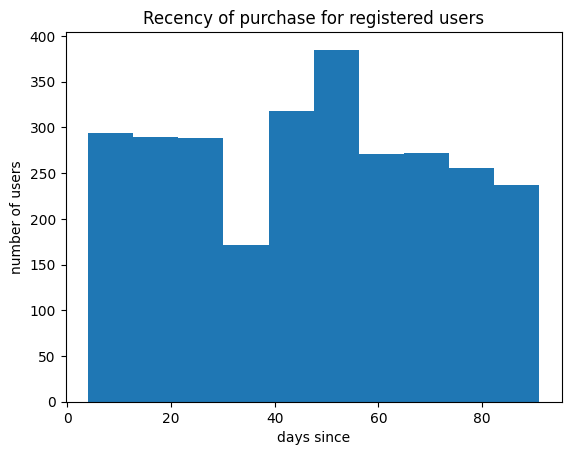

In [ ]:
# take purchase rows for registered users only
reg_purchases = sales_df[sales_df['registered_account_id'].notna() & sales_df['product_price_per_item'].notna()].copy()
reg_purchases['session_and_order_date'] = pd.to_datetime(reg_purchases['session_and_order_date'])

end_of_window = pd.Timestamp(sales_df['session_and_order_date'].max())

recency = (end_of_window - reg_purchases.groupby('registered_account_id')['session_and_order_date'].max()).dt.days

recency.hist(grid=False)
plt.xlabel('days since')
plt.ylabel('number of users')
plt.title('Recency of purchase for registered users')
plt.show()

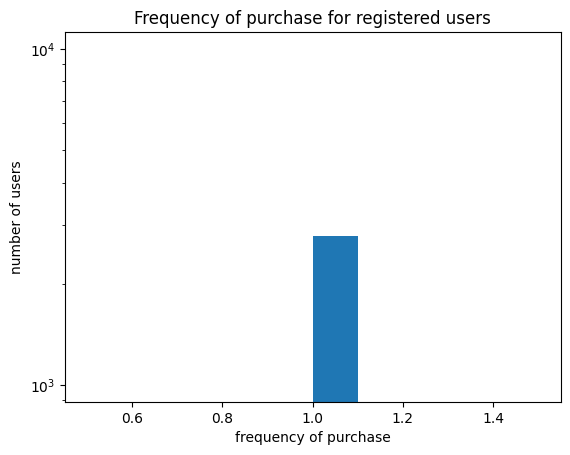

In [ ]:
# frequency of purchase for registered users who made purchase
frequency = reg_purchases.groupby('registered_account_id')['product_price_per_item'].count()

frequency.hist(grid=False)
plt.yscale("log") # check if there are any hidden bars obscured due to a small difference in frequency
plt.xlabel('frequency of purchase')
plt.ylabel('number of users')
plt.title('Frequency of purchase for registered users')
plt.show()

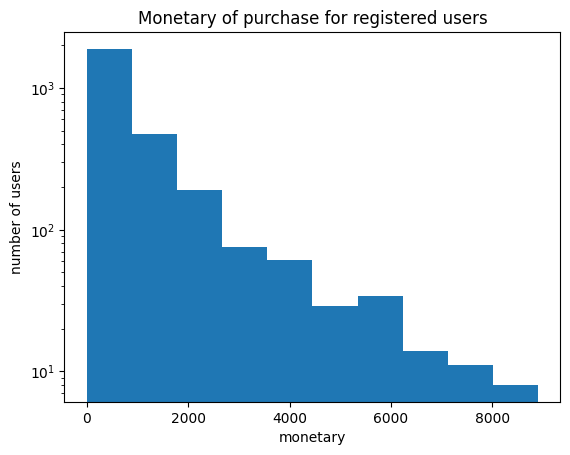

In [ ]:
# monetary of purchase for registered users who made purchase
monetary = reg_purchases.groupby('registered_account_id')['product_price_per_item'].sum()

monetary.hist(grid=False)
plt.yscale('log')
plt.xlabel('monetary')
plt.ylabel('number of users')
plt.title('Monetary of purchase for registered users')
plt.show()

To score users on recency, frequency, and monetary value, each metric needs to show spread across users. Frequency has none in this dataset — every registered user made exactly one purchase within the 3-month window — so scoring it would be meaningless. Further analysis (scoring and segmentation) will therefore use recency and monetary value only, effectively reducing RFM to RM segmentation.

In [ ]:
rfm = reg_purchases.groupby('registered_account_id').agg(last_purchase=('session_and_order_date', 'max'), frequency=('product_price_per_item', 'count'), monetary=('product_price_per_item', 'sum'))
rfm['recency'] = (end_of_window - rfm['last_purchase']).dt.days

rfm = rfm.drop(columns='last_purchase')

# scoring
rfm['r_score'] = pd.qcut(x=rfm['recency'], q=4, labels=([4, 3, 2, 1])) # reversed: lowest days-since-purchase gets the highest score
rfm['m_score'] = pd.qcut(x=rfm['monetary'], q=4, labels=[1, 2, 3, 4])

# combined-scoring
rfm['rm'] = rfm['r_score'].astype(str) + rfm['m_score'].astype(str)


check = rfm.groupby("rm").agg(users=("recency", "size"),
                      avg_recency=("recency", "mean"),
                      avg_monetary=("monetary", "mean"))

display("Result check:", check)

'Result check:'

,users,avg_recency,avg_monetary
rm,,,
11,165,79.509091,69.698788
12,163,79.730061,285.977301
13,177,78.768362,720.889831
14,163,79.478528,2721.761963
21,176,56.931818,70.925000
22,172,57.546512,277.740116
23,185,57.654054,712.904865
24,175,57.565714,2881.415429
31,172,37.918605,66.791279


Segment logic:
* Low: scores 1-2
* High: scores 3-4

|              | M high (3–4) | M low (1–2) |
|--------------|--------------|-------------|
| **R high (3–4)** | Champions | Recent budget buyers |
| **R low (1–2)**  | Stale big spenders | Hibernating |

In [ ]:
def label_segment(row):
    r, m = int(row["r_score"]), int(row["m_score"])
    if r >= 3 and m >= 3:
        return "champions"
    elif r >= 3 and m <= 2:
        return "recent budget buyers"
    elif r <= 2 and m >= 3:
        return "stale big spenders"
    else:
        return "hibernating"

rfm["segment"] = rfm.apply(label_segment, axis=1)

display(rfm)

,frequency,monetary,recency,r_score,m_score,rm,segment
registered_account_id,,,,,,,
636138,1,395.0,91,1,2,12,hibernating
636139,1,125.0,80,1,1,11,hibernating
636155,1,89.0,68,1,1,11,hibernating
636164,1,280.0,55,2,2,22,hibernating
636184,1,395.0,44,3,2,32,recent budget buyers
...,...,...,...,...,...,...,...
681852,1,695.0,61,2,3,23,stale big spenders
681875,1,240.0,79,1,2,12,hibernating
681888,1,59.0,66,2,1,21,hibernating


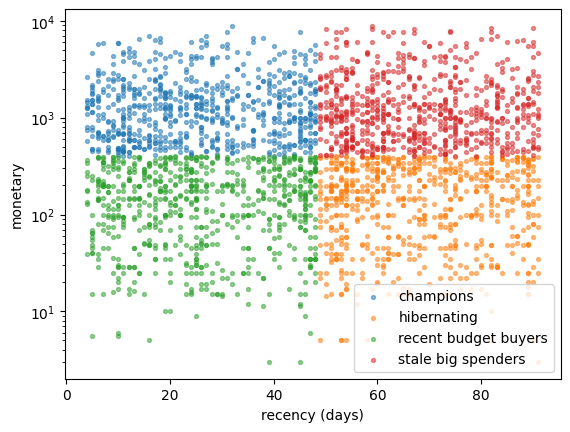

In [ ]:
for name, grp in rfm.groupby("segment"):
    plt.scatter(grp["recency"], grp["monetary"], s=8, alpha=0.5, label=name)
plt.yscale("log")
plt.xlabel("recency (days)")
plt.ylabel("monetary")
plt.legend()
plt.show()

# Does Newsletter Amplify Behavior?

**Business question:** Does newsletter subscription amplify purchase behavior for registered users and act as a conversion driver for unregistered users — or do subscribers simply have inherently higher engagement?

**Inference:**

**Subscription status does not meaningfully change purchase behavior within the registered segment, and by design cannot affect the unregistered majority**. This mirrors the registered vs unregistered result (\~$1 difference) — engagement-status segments are behaviorally uniform.

No subscription-based differentiation of pricing or promotions is justified. The newsletter's value, if any, lies in retention/re-activation effects not measurable in this 3-month window which still requires confirmation.

Consistent with Sections 3–5, where conversion and revenue per session were uniform across channels, devices, and segments, pointing to external demand and category pricing as the dominant drivers.

## Revenue & Average Revenue per Session Comparison

In [ ]:
subscr_users_sessions = sales_df[sales_df['is_unsubscribed_from_newsletter'] == 0]
unsubscr_users_sessions = sales_df[sales_df['is_unsubscribed_from_newsletter'] == 1]

subscr_rps = subscr_users_sessions['product_price_per_item'].sum() / subscr_users_sessions['session_id'].nunique()

unsubscr_rps = unsubscr_users_sessions['product_price_per_item'].sum() / unsubscr_users_sessions['session_id'].nunique()

print(f'subscr_rps: {subscr_rps}')
print(f'unsubscr_rps: {unsubscr_rps}')

subscr_rps: 92.66682033606205
unsubscr_rps: 91.17668426610348


In [ ]:
subscr_session_revenue = (
    subscr_users_sessions
    .groupby('session_id')['product_price_per_item']
    .sum()
)

unsubscr_session_revenue = (
    unsubscr_users_sessions
    .groupby('session_id')['product_price_per_item']
    .sum()
)

stat, p_value = stats.mannwhitneyu(subscr_session_revenue, unsubscr_session_revenue, alternative='two-sided')

print(f'p_value: {p_value}')
if p_value < 0.05:
  print('The difference between groups is statistically significant')
else:
  print('The difference between groups is NOT statistically significant')

p_value: 0.2279139907980643
The difference between groups is NOT statistically significant


# Localization

**Business questions:** What languages do our users prefer across top markets, and is there evidence that language mismatch suppresses conversion or revenue?

**Inference:**

Browser-language composition is nearly identical across all top-5 markets: \~87% of sessions prefer English, with Chinese (~5%) the largest minority and French only 2.3% even in France. No market contains a non-English cluster large enough to represent a meaningful localization opportunity.

Whether users are served in their preferred language cannot be assessed: the site's served language is not recorded.

**Data-quality note:** the near-identical language mix across countries is itself suspicious. In real traffic, browser language correlates strongly with geography (France would show a substantial fr share). Uniform distribution suggests this field is synthetically generated or corrupted at collection — recommend a tracking audit before using it for decisions.

**Conclusion:** no evidence supports localization investment.

In [ ]:
sales_df['lang_missing'] = sales_df['browser_language'].isna()

print(sales_df.groupby('browser')['lang_missing'].mean().round(3))

print(sales_df.groupby('device')['lang_missing'].mean().round(3))

top5 = ['United States', 'India', 'Canada', 'United Kingdom', 'France']
print(sales_df[sales_df['country'].isin(top5)].groupby('country')['lang_missing'].mean().round(3))

browser
<Other>            0.320
Android Webview    0.308
Chrome             0.328
Edge               0.325
Firefox            0.338
Safari             0.326
Name: lang_missing, dtype: float64
device
desktop    0.326
mobile     0.328
tablet     0.330
Name: lang_missing, dtype: float64
country
Canada            0.323
France            0.325
India             0.323
United Kingdom    0.320
United States     0.326
Name: lang_missing, dtype: float64


Missingness in browser_language is uniform (~32–33%) across every browser, device, and top-5 country — no segment is disproportionately affected. The remaining 67% of sessions form a representative sample, and we proceed with nulls dropped.

In [ ]:
lang_df = sales_df.dropna(subset=['browser_language']).copy()
lang_df['lang'] = lang_df['browser_language'].str.split('-').str[0]

top5 = ['United States', 'India', 'Canada', 'United Kingdom', 'France']
lang_top = lang_df[lang_df['country'].isin(top5)]

lang_mix = pd.crosstab(lang_top['country'], lang_top['lang'], normalize='index').round(3)
print(lang_mix)

lang               de     en     es     fr     ko     zh
country                                                 
Canada          0.014  0.875  0.025  0.022  0.010  0.053
France          0.013  0.872  0.026  0.023  0.013  0.053
India           0.014  0.873  0.026  0.025  0.011  0.051
United Kingdom  0.018  0.876  0.024  0.023  0.009  0.051
United States   0.014  0.874  0.024  0.024  0.012  0.051


# Is There Seasonality for the Business?

**Inference:**

**There is seasonality — but weekly, not annual.** A 3-month window can only reveal short-cycle seasonality. The strongest pattern in this analysis is the weekly rhythm; annual seasonality is unmeasurable here and requires 1–2+ years of data.

**Trend: holiday calendar, not growth.** Revenue climbs from mid-November to a mid-December peak (Black Friday, pre-Christmas demand), falls sharply as holiday delivery windows close, then recovers and stabilises around 380,000 per day through January. This is the shape of the holiday season, not a business trajectory.

**Weekly rhythm: the strongest operational lever found in this project.** Deviation from the trend level, USD:

| Day | Deviation | % of level |
|---|---|---|
| Tuesday | +53,700 | +15% |
| Wednesday | +53,500 | +15% |
| Thursday | +59,700 | +16% |
| Monday | −5,900 | −2% |
| Friday | +3,400 | +1% |
| Saturday | −71,200 | −20% |
| Sunday | −88,700 | −24% |

The swing between best and worst day is 148,400. Weekend weakness is counterintuitive for furniture retail, so its source was verified: session volume drops in parallel (Saturday 39,523 and Sunday 39,702 vs Tuesday 58,523 — about 32% lower). The rhythm is driven by **traffic, not conversion** — users simply visit less at weekends. This is an acquisition question.

**Component magnitudes.** Standard deviation shows how much revenue each component moves: trend 54,300, seasonal 62,800, residual 51,000. All three are comparable, with the weekly cycle marginally largest. Daily volatility is high throughout (raw revenue 200,000–680,000 per day), and the residual captures sharp single-day spikes around Black Friday and mid-January — demand is event-driven rather than steady, consistent with findings across this report.

**Recommendation:** align campaign timing, email sends and support staffing to the midweek peak; treat weekend softness as a traffic-acquisition test, not a conversion fix. Plan promotions against the residual where events are known in advance.

**Data note:** Jan 28–31 carry zero purchases (confirmed genuine low-demand boundary days, not missing data) and were excluded from decomposition — at the window edge they deflate the rolling average mechanically and cannot be read as a downward trend.

## Overall Sales Dynamics

**Business questions:** What does our overall revenue trend look like — are we growing, declining, or flat — and how much volatility exists around the underlying trend?

**Inference:**

The 7-day average rises from mid-November, peaking in early-to-mid December — consistent with Black Friday and pre-Christmas demand. It then declines through late December, likely as holiday delivery windows close, before recovering and stabilizing around \$380,000 per day through January. **Daily volatility is high** throughout (raw revenue ranges roughly \$200,000–$680,000 per day), with sharp single-day spikes around Black Friday and mid-January that the smoothed line absorbs — demand is event-driven rather than steady.

**Note:** Revenue drops to zero on Jan 28–31 (confirmed genuine low-demand days at the window boundary). Because this occurs at the edge of the observation window, it cannot be interpreted as a sustained downward trend, and the rolling average across these dates is mechanically deflated by the zeros rather than reflecting a gradual decline.

In [ ]:
daily_rythm = sales_df.groupby('session_and_order_date')['product_price_per_item'].sum().reset_index().sort_values(by='session_and_order_date', ascending=True).rename(columns={'session_and_order_date': 'date','product_price_per_item': 'revenue' })
daily_rythm['7_day_rolling'] = daily_rythm['revenue'].rolling(7).mean()

display(daily_rythm)

,date,revenue,7_day_rolling
0,2020-11-01,244292.5,NaN
1,2020-11-02,355506.8,NaN
2,2020-11-03,498979.6,NaN
3,2020-11-04,339187.1,NaN
4,2020-11-05,391276.6,NaN
...,...,...,...
87,2021-01-27,286340.7,327518.528571
88,2021-01-28,0.0,268932.357143
89,2021-01-29,0.0,213987.314286
90,2021-01-30,0.0,172472.242857


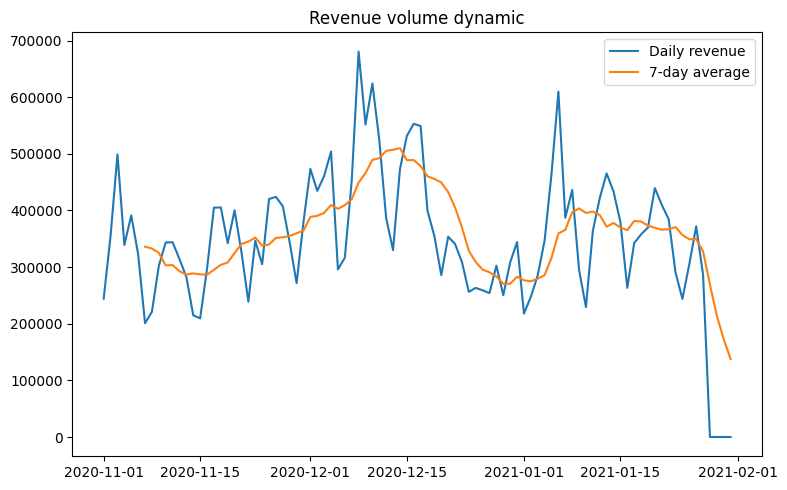

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(daily_rythm['date'], daily_rythm['revenue'], label='Daily revenue')
ax.plot(daily_rythm['date'], daily_rythm['7_day_rolling'], label='7-day average')

plt.title('Revenue volume dynamic')
plt.legend()
plt.tight_layout()
plt.show()

## STL Decomposition

**Business questions:** What is our business weekly rythm, should we plan campaings, promotions for specific week days?

**Inference:**

**Trend.**
Over the observed window (2020-11-01 to 2021-01-31) the trend is **holiday-driven rather than structural**: revenue climbs from mid-November through a mid-December peak (Black Friday, pre-Christmas demand), drops sharply as holiday delivery windows close, then recovers to a stable level in January. **With only three months of data this reflects the holiday calendar, not business growth.** Assessing a yearly trend would require 1–2 years of data, which is outside the scope of this analysis.

**Weekly rhythm (seasonal).**
Midweek dominates, weekends collapse. Deviation from the trend level, USD:

| Day | Deviation | % of level |
|---|---|---|
| Tuesday | +53,700 | +15% |
| Wednesday | +53,500 | +15% |
| Thursday | +59,700 | +16% |
| Monday | −5,900 | −2% |
| Friday | +3,400 | +1% |
| Saturday | −71,200 | −20% |
| Sunday | −88,700 | −24% |

The swing between the best and worst day is 148,400 — roughly 41% of the average daily level.
Weekend weakness is counterintuitive for furniture retail, so its source was verified: session volume drops in parallel (Saturday 39,523 and Sunday 39,702 sessions vs Tuesday 58,523 — about 32% lower). The weekly revenue rhythm is therefore driven by **traffic, not conversion** — users simply visit less at weekends. This makes it an acquisition question rather than a site-optimisation one.

**Component magnitudes.** Standard deviation of each component shows how much revenue it moves: trend 54,300, seasonal 62,800, residual 51,000. All three are comparable, with the weekly cycle marginally largest. No single component dominates, but the weekly rhythm is the only one predictable in advance; the residual (Black Friday spikes, mid-January promotions) confirms the event-driven demand pattern found throughout this report — and is partly plannable when campaigns and holidays are scheduled in advance.

**Recommendation:** align campaign timing, email sends and support staffing to the midweek peak. Test weekend traffic acquisition separately. Annual seasonality cannot be assessed from a 3-month window and requires 1–2+ years of data.

0


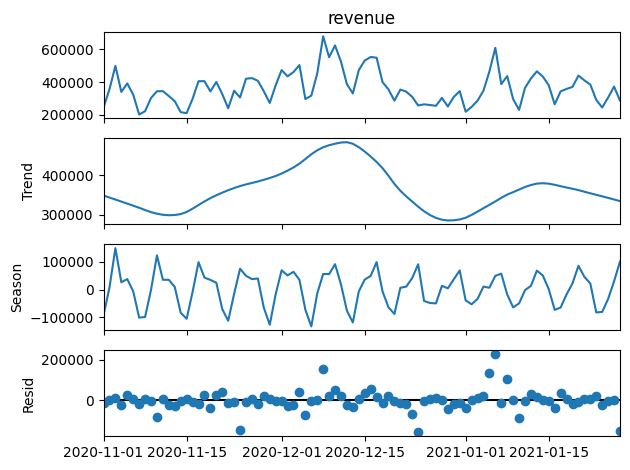

In [ ]:
from statsmodels.tsa.seasonal import STL

daily_rythm['date'] = pd.to_datetime(daily_rythm['date'])
# removing 0-revenue days to preserve data cleanness
s = daily_rythm[daily_rythm['date'] <= '2021-01-27'].set_index('date')['revenue'].asfreq('D')
print(s.isna().sum())
daily_rythm
stl = STL(s, period=7, robust=True).fit()
stl.plot()
plt.show()


In [ ]:
print(stl.trend.std(), stl.seasonal.std(), stl.resid.std())

54307.23797359674 62825.588266213155 50975.56007157824


In [ ]:
baseline = stl.trend.mean()

weekly = stl.seasonal.groupby(stl.seasonal.index.dayofweek).mean().to_frame('revenue')
weekly['pct_of_baseline'] = weekly['revenue'] / baseline * 100
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly.index = days
weekly['stl_trend_mean_as_baseline'] = baseline

swing_usd = weekly['revenue'].max() - weekly['revenue'].min()
print(weekly.round(1))
print(f'Swing: ${swing_usd:,.0f} ({swing_usd / baseline * 100:.1f}% of baseline)')

     revenue  pct_of_baseline  stl_trend_mean_as_baseline
Mon  -5924.5             -1.6                    363032.6
Tue  53691.4             14.8                    363032.6
Wed  53502.9             14.7                    363032.6
Thu  59692.6             16.4                    363032.6
Fri   3441.1              0.9                    363032.6
Sat -71162.7            -19.6                    363032.6
Sun -88748.0            -24.4                    363032.6
Swing: $148,441 (40.9% of baseline)


In [ ]:
sales_df['session_and_order_date'] = pd.to_datetime(sales_df['session_and_order_date'])
sales_df['weekday'] = sales_df['session_and_order_date'].dt.day_name()
traffic = sales_df.groupby('weekday')['session_id'].count().to_frame('sessions')
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traffic = traffic.reindex(days)
traffic

,sessions
weekday,
Monday,50069
Tuesday,58523
Wednesday,57990
Thursday,54135
Friday,49603
Saturday,39523
Sunday,39702


# Conclusions & Recommendations

## Key Findings

**F1. Weekly rhythm is the strongest operational lever in the dataset.**

STL decomposition (period=7, robust) on daily revenue gives a seasonal component with a peak-to-trough swing of 148,400 USD, against an average daily level near 360,000 USD.

The mechanism is identified — the weekend gap is a traffic gap, not a conversion gap (Sat 39,523 and Sun 39,702 sessions vs Tue 58,523, −32%). This is an acquisition and scheduling question, not a site-optimization one.

| Day | Deviation | % of level |
|---|---|---|
| Tuesday | +53,700 | +15% |
| Wednesday | +53,500 | +15% |
| Thursday | +59,700 | +16% |
| Monday | −5,900 | −2% |
| Friday | +3,400 | +1% |
| Saturday | −71,200 | −20% |
| Sunday | −88,700 | −24% |
  

**F2 — User behaviour is uniform across every segmentation tested**
| Segmentation | Result | Practical read |
|---|---|---|
| Device / browser / OS | No significant difference; revenue per session 90–92 USD | No platform-specific investment |
| Traffic channel | Conversion 9.58–9.73%, χ²(4)=0.64, p=0.96 | No channel-specific strategy |
| Country (top 5) | All bootstrap CIs overlap the store median | Geography drives volume, not per-session value |
| Registered vs unregistered | 92.41 vs 91.38 USD, p=0.047 | Significant, ~1% — overpowered test, not a lever |
| Newsletter subscribed vs not | 92.67 vs 91.17 USD, p=0.228 | Not significant; retention channel, not a revenue lever |
| Browser language mix by country | Near-identical across all top-5 markets | No localization gap detectable |

With 33,000+ purchase rows the tests are overpowered: trivial differences reach significance. This is why every result above was checked against a bootstrap CI and an effect size rather than a p-value alone. The 1 USD registration difference is the clearest example — statistically real, commercially irrelevant.

The strategic implication is a decision not to spend. A unified global approach is the correct default.

**F3 - Value differences are a category story, not a geography story**
| Category | Median | vs store median |
Price distribution reveals three distinct positioning tiers (median product price):
* **Premium** — Sofas & armchairs (\$1,176), Beds (\$1,095), Cabinets & cupboards (\$841). All sit far above the store median (\$445) with CIs that clear it by a wide margin.
* **At baseline** — Bar furniture (\$435) and Chests of drawers (\$460) are the only categories whose CIs overlap the store median; they define the store's price centre.
* **Budget** — Children's furniture (\$195), Bookcases & shelving units (\$235), Outdoor furniture (\$356), Tables & desks (\$376), Chairs (\$395). All reliably below baseline.

Category concentration has the same mix in all top-5 countries (US, Canada, India, France, UK) and in all continents, so no localized assortment strategy is indicated.

**F4 — Demand is externally driven**
| Comovement (Spearman, daily) | Range |
|---|---|
| Between product categories | 0.31–0.81 (Bookcases, Chairs, Sofas, Beds and Tables intercorrelate at ρ ≥ 0.68. The strongest: Bookcases × Sofas (0.81) and Chairs × Sofas (0.80).)|
| Between countries | 0.13–0.56 (weakest FR×UK 0.13, strongest US×CA 0.56) |
| Between continents | 0.61–0.67 (weakest Asia×Europe 0.61, strongest America×Asia 0.67) |

Product demand is more varied and specific categories synchronize more tightly than market demand. Practically: a single global promotional calendar is the right baseline, and campaign timing should be coordinated across categories rather than staggered.

## Recommendations

### High priority — act this quarter

**R1. Align operations and campaign timing to the weekly cycle.**

Action: Schedule email sends, promotional launches and site merchandising changes for Tue–Thu, when users are already on site. Staff support and fulfilment to the same peak

Cost: zero incremental budget — same spend, same headcount, different calendar.

Success metric: email and promo engagement rate, email CTR, open rate

**R2. Consolidate to a single global promotional calendar and retire segment-specific plans.**

Action: Any existing device-, channel-, or country-specific marketing and merchandising plan should be justified against evidence or discontinued.

Cost: negative - release budget and coordination overhead.

Success metric: revenue per session and conversion hold flat

**R3. Classification of Undefined traffic channel.**
Action: Identify and estbalish a classification for the Undefined traffic channel.

Cost: engineering team effort (budget, time)

Success metric: instead of undefined channel real segments are used and prepopulated in the dataset

**R4. Browser-langugae data collection fix**

Action: Investigate and fix browser-language data collection issue.

Cost: engineering effort (budget, time).

Success metric: browser_language is populated in the dataset.

**R5. Investigate low traffic on weekends reasons**
Action: Investigate reasons of low traffic on weekends and decide if possible to use for further hypothesis, tests.

Cost: investigation time of the product/business teams.

Success metric: reasons are clear, next steps are identified.

**R6. Start gathering order_id and quantity fields**
To enable true AOV, basket size and item quantity analysis.

Action: Start gathering order_id and quantity.

Cost: engineering effort (budget, time).

Success metric: order_id and quantity fields are populated in the dataset.


### Medium priority — plan and test next quarter
**R7. Run a price-sensitivity test on Bookcases & shelving units (category in top-5 by revenue and with the highest demand).**

Design and thresholds in Hypothesis 1.

Cost: test design effort. Success metric: revenue per session within the Bookcases category, treatment vs control.


### Low priority - monitor, do not fund yet

**R8. Treat France/UK/India promotional timing as a stretch goal only.** FR×UK is the weakest country pair (0.13), while India has weak-moderate correlation with any other top country - which is the only hint of independent timing anywhere in the data.


## Hypotheses for Further Testing

**H1 — Bookcases demand is price-inelastic enough that a price increase raises category revenue**
- Basis: Bookcases & shelving units carry the highest order volume in the store at on of the lowest median item price (235 USD against a store median of 445 USD, non-overlapping bootstrap CI — Section 5). High volume at a low price point is a reason to test price sensitivity
- Hypothesis: If we increase the SKU by 30% in Bookcases category, then we belive our revenue will grow at least by 10%, while order volume will not drop more than by 15.4%
- Test: Randomised SKU-level price test. Users are assigned to price cells; assignment is by user, not by geography. Control: current prices. Treatment: every Bookcases SKU raised 30%. Duration set by the sample needed for the target MDE.
- Primary metric: Bookcases category revenue
- Guardrail metric: Store-wide revenue per session - no drop, order volume drop no more than 15.4%
- Size of prize. 10% of category revenue.
- Precondition: define duration and sample size for the test.

**H2 — Locally timed promotions outperform globally timed ones in the least synchronised markets**
- Basis: Daily revenue correlation across the top-5 countries is weak to moderate (ρ = 0.13–0.56), France × UK is the weakest pair at ρ = 0.13 and is not significant after FDR correction
- Hypothesis: If we run localized campaigns by local calendar instead of global calendar for India, France and UK - our revenue will improve by at least 5% (business decision).
- Test: A/B for each country: control group - global calendar promo, tratment group - local calendar promo. Duration set by the sample needed for the target MDE.
- Primary metric: daily country revenue
- Guardrail metric: none
- Size of prize: 5% increase in revenue of a specified country.
- Precondition: define duration and sample size for the test.

**H3. Social traffic can be scaled profitably**
- Basis: Social generates revenue per session comparable to the top channels despite far lower volume, and conversion is statistically identical across all channels (9.58–9.73%, χ²(4) = 0.64, p = 0.96
- Hypothesis: If we increase CAC for Social channel we will organically increase revenue while maintaning acceptable investment.
- Test: Step one: pull historical cost per session by channel from the ad platforms — no test needed, the data already exists. Only if Social CAC sits below the threshold does step two follow: a budget uplift with a holdout, measuring whether cost per session holds as spend scales.
- Primary metric: Cost per acquired session in Social channel.
- Guardrail metric: Revenue per session within Social (to check if traffic value is around benchmark or worth less)
- Size of prize: [compute]% increase in revenue (clarify with the financial team)
- Precondition: define duration and sample size for the test.




## Analytical Limitations

- Window length (constrains everything). 92 days, holiday-heavy (Black Friday, Christmas, New Year). Consequences: annual seasonality is unobservable — 0.25 of a cycle, where STL requires at least two; the trend component reflects the holiday calendar, not structural growth; no repeat-purchase behaviour is observed, so no lifecycle, cohort, churn or LTV analysis is possible; RM segment labels describe position within a holiday window.

- No order_id (constrains all value metrics). True AOV, basket size and item quantity cannot be computed.

- Overpowered tests. With 33,000+ purchase rows, differences of ~1% reach p < 0.05. Practical significance was therefore assessed separately in every case via bootstrap CI and effect size. Any p-value in this report should be read alongside its effect size.

- Correlation, not causation. Every association reported here is observational. No causal claim is made.

- browser_language is unreliable and localization is unmeasurable. 32.6% missing, but the field fails a cross-field consistency check against country and is likely synthetic or corrupted. Separately, the site's served language is not recorded, so whether users are served in their locale cannot be assessed at all — browser language is demand-side only.

- Boundary days excluded. Jan 28–31 carry zero purchases — verified as genuine low-demand boundary days, not missing data. They were excluded from decomposition and daily correlation because at the window edge they deflate the trend mechanically and would read as a false decline.

- Data freshness. The window closed 2021-01-31. Findings describe that period and should not be assumed to hold for current trading conditions, product mix, or user behaviour.

- Hypothesis in the previous section should be worked upon to be ready for testing.

# Export pre-aggregated CSVs for Tableau



In [ ]:
# sales_df.head()
sales_df['weekday'] = sales_df['session_and_order_date'].dt.dayofweek
sales_df['weekday_name'] = sales_df['session_and_order_date'].dt.strftime('%a')

sessions = sales_df[[
    'session_id', 'session_and_order_date', 'weekday', 'weekday_name',
    'product_category', 'browser', 'device', 'operating_system',
    'country', 'continent', 'traffic_channel', 'product_price_per_item',
    'product_id', 'registered_account_id', 'is_unsubscribed_from_newsletter'
]].copy()

sessions['is_registered'] = np.where(
    sessions['registered_account_id'].notna(), 'registered', 'anonymous'
)

sessions['subscription_status'] = sessions['is_unsubscribed_from_newsletter'].map(
    {0: 'subscribed', 1: 'unsubscribed'}
).fillna('never_subscribed')

sessions = sessions.drop(columns=['is_unsubscribed_from_newsletter'])
sessions = sessions.rename(columns={'session_and_order_date': 'session_date', })

display(sessions)

,session_id,session_date,weekday,weekday_name,product_category,browser,device,operating_system,country,continent,traffic_channel,product_price_per_item,product_id,registered_account_id,is_registered,subscription_status
0,5760483956,2020-11-01,6,Sun,Bookcases & shelving units,Chrome,desktop,Macintosh,United States,Americas,Paid Search,609.0,99902661,<NA>,anonymous,never_subscribed
1,7115337200,2020-11-01,6,Sun,Bookcases & shelving units,Chrome,desktop,Web,United Kingdom,Europe,Organic Search,609.0,99902661,<NA>,anonymous,never_subscribed
2,3978035233,2020-11-01,6,Sun,Tables & desks,Chrome,mobile,Web,Norway,Europe,Direct,189.0,20382932,<NA>,anonymous,never_subscribed
3,9648986282,2020-11-01,6,Sun,Bookcases & shelving units,Chrome,mobile,Android,Nigeria,Africa,Direct,609.0,99902661,<NA>,anonymous,never_subscribed
4,4393441533,2020-11-01,6,Sun,Bookcases & shelving units,Chrome,desktop,Windows,China,Asia,Direct,609.0,99902661,<NA>,anonymous,never_subscribed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349540,5756982967,2021-01-31,6,Sun,None,Firefox,desktop,Windows,Ukraine,Europe,Social Search,NaN,<NA>,<NA>,anonymous,never_subscribed
349541,464560636,2021-01-31,6,Sun,None,Edge,desktop,Web,United States,Americas,Organic Search,NaN,<NA>,<NA>,anonymous,never_subscribed
349542,6336117447,2021-01-31,6,Sun,None,Chrome,desktop,Web,United States,Americas,Direct,NaN,<NA>,<NA>,anonymous,never_subscribed
349543,4958826563,2021-01-31,6,Sun,None,Safari,mobile,iOS,India,Asia,Undefined,NaN,<NA>,<NA>,anonymous,never_subscribed


In [ ]:
weekly_seasonal = weekly.copy()
weekly_seasonal = weekly_seasonal.reset_index().rename(columns={'index': 'weekday_name'})
weekly_seasonal = weekly_seasonal.reset_index().rename(columns={'index': 'weekday', 'revenue': 'revenue_deviation'})
weekly_seasonal

,weekday,weekday_name,revenue_deviation,pct_of_baseline,stl_trend_mean_as_baseline
0,0,Mon,-5924.515087,-1.631951,363032.632905
1,1,Tue,53691.421029,14.789696,363032.632905
2,2,Wed,53502.887336,14.737763,363032.632905
3,3,Thu,59692.613249,16.442768,363032.632905
4,4,Fri,3441.111473,0.947879,363032.632905
5,5,Sat,-71162.726421,-19.602295,363032.632905
6,6,Sun,-88747.983262,-24.446283,363032.632905


In [ ]:
category_ci = cat_filtered_median_ci.copy().rename(columns={'group': 'product_category', 'n': 'purchase_number'})

store_median = category_ci.loc[category_ci['product_category'] == 'TOTAL', 'median'].iloc[0]
category_ci = category_ci[category_ci['product_category'] != 'TOTAL'].copy()
category_ci['store_median'] = store_median
category_ci = category_ci.sort_values('median', ascending=False).reset_index(drop=True)

category_ci

,product_category,purchase_number,median,ci_lower,ci_upper,ci_width,overlaps_total,store_median
0,Sofas & armchairs,4301,1176.0,1100.0,1250.0,150.0,False,445.0
1,Beds,2926,1095.0,1092.0,1145.0,53.0,False,445.0
2,Cabinets & cupboards,2318,841.0,777.0,925.0,148.0,False,445.0
3,Chests of drawers & drawer units,1452,460.0,445.0,495.0,50.0,True,445.0
4,Bar furniture,1092,435.0,395.0,445.0,50.0,True,445.0
5,Chairs,5952,395.0,385.0,425.0,40.0,False,445.0
6,Tables & desks,2941,376.0,356.0,395.0,39.0,False,445.0
7,Outdoor furniture,2229,356.0,340.0,385.0,45.0,False,445.0
8,Bookcases & shelving units,7630,235.0,225.0,250.0,25.0,False,445.0
9,Children's furniture,1702,195.0,175.0,205.0,30.0,False,445.0


In [ ]:
dims = {
    'browser': 'browser',
    'device': 'device',
    'operating_system': 'operating_system',
    'channel': 'traffic_channel',
    'country': 'country',
    'registration': 'is_registered'
}

cat_median_diff_filtered = category_median_diff[category_median_diff['group'].isin(top_10_categories_by_revenue + ['TOTAL'])]

frames = []
for label, col in dims.items():
    out = calc_median_ci(sessions, 'product_price_per_item', col)
    out = out[out['group'] != 'TOTAL'].copy()
    out['segment_type'] = label
    if col == dims['country']:
      out = out[out['group'].isin(top_5_countries_by_revenue)]
    frames.append(out)

segment_ci = pd.concat(frames, ignore_index=True)
segment_ci = segment_ci.rename(columns={'group': 'segment', 'n': 'purchase_number'})
segment_ci['store_median'] = sales_df['product_price_per_item'].median()
segment_ci = segment_ci[['segment_type', 'segment', 'median',
                         'ci_lower', 'ci_upper', 'ci_width', 'purchase_number', 'store_median', 'overlaps_total']]


In [ ]:
display(segment_ci)

,segment_type,segment,median,ci_lower,ci_upper,ci_width,purchase_number,store_median,overlaps_total
0,browser,<Other>,475.0,404.8500,500.00000,95.15000,865,445.0,True
1,browser,Edge,450.0,395.0000,544.70000,149.70000,752,445.0,True
2,browser,Android Webview,445.0,394.8750,512.00000,117.12500,420,445.0,True
3,browser,Chrome,445.0,435.0000,450.00000,15.00000,23015,445.0,True
4,browser,Safari,445.0,420.0000,460.00000,40.00000,7903,445.0,True
5,browser,Firefox,435.0,395.0000,495.00000,100.00000,583,445.0,True
6,device,tablet,495.0,445.0000,554.00000,109.00000,723,445.0,True
7,device,desktop,445.0,440.0000,458.00000,18.00000,19702,445.0,True
8,device,mobile,435.0,415.0000,449.00000,34.00000,13113,445.0,True
9,operating_system,<Other>,495.0,425.0000,518.79375,93.79375,882,445.0,True


In [ ]:
# === Tableau extracts ===
# from google.colab import drive
# from pathlib import Path

# drive.mount('/content/drive')
# # paste the real path of your project
# rel = userdata.get('drive_export_path').strip().lstrip('/')
# OUT = Path('/content/drive') / rel
# OUT.mkdir(parents=True, exist_ok=True)

# def export(df, name):
#     path = OUT / f'{name}.csv'
#     df.to_csv(path, index=False, encoding='utf-8-sig', na_rep='')
#     print(f'{name:22} {df.shape[0]:>7,} rows × {df.shape[1]:>2} cols'
#           f'  {path.stat().st_size / 1e6:>6.1f} MB')

# export(sessions, 'sessions')
# export(weekly_seasonal, 'weekly_seasonal')
# export(category_ci, 'category_ci')
# export(segment_ci, 'segment_ci')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
sessions               349,545 rows × 16 cols    39.2 MB
weekly_seasonal              7 rows ×  5 cols     0.0 MB
category_ci                 10 rows ×  8 cols     0.0 MB
segment_ci                  27 rows ×  9 cols     0.0 MB
